In [4]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

try:
    from xgboost import XGBRegressor
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print("⚠️  XGBoost not available — will skip")

try:
    from lightgbm import LGBMRegressor
    LGB_OK = True
except ImportError:
    LGB_OK = False
    print("⚠️  LightGBM not available — will skip")

warnings.filterwarnings('ignore')
RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Environment configured")
print(f"   NumPy  {np.__version__}")
print(f"   Pandas {pd.__version__}")

⚠️  XGBoost not available — will skip
✅ Environment configured
   NumPy  2.1.3
   Pandas 2.2.3


In [5]:
print("🔍 Scanning /kaggle/input ...\n")
all_files, csv_files = [], []

for dirname, _, filenames in os.walk('d:\Visul Studio\Global Petrol Prices — Impact of 2026 US-Iran War'):
    for fn in filenames:
        fp = os.path.join(dirname, fn)
        all_files.append(fp)
        if fn.endswith('.csv'):
            csv_files.append(fp)
        print(f"   {fp}")

print(f"\n📊 Discovery Summary:")
print(f"   Total files : {len(all_files)}")
print(f"   CSV files   : {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError("❌ No CSV files found! Attach the dataset first.")
print("\n✅ CSVs discovered — proceeding to load")

🔍 Scanning /kaggle/input ...

   d:\Visul Studio\Global Petrol Prices — Impact of 2026 US-Iran War\country_impact.csv
   d:\Visul Studio\Global Petrol Prices — Impact of 2026 US-Iran War\crude_oil_daily.csv
   d:\Visul Studio\Global Petrol Prices — Impact of 2026 US-Iran War\petrol_prices_comparison.csv
   d:\Visul Studio\Global Petrol Prices — Impact of 2026 US-Iran War\pros_cons_analysis.csv
   d:\Visul Studio\Global Petrol Prices — Impact of 2026 US-Iran War\README.md
   d:\Visul Studio\Global Petrol Prices — Impact of 2026 US-Iran War\war_timeline.csv

📊 Discovery Summary:
   Total files : 6
   CSV files   : 5

✅ CSVs discovered — proceeding to load


In [6]:
# ── Smart loader: match each CSV by keywords in filename ──────────────────
def load_csv_smart(keyword_map, csv_files):
    """
    keyword_map = {'key': ['kw1','kw2']}  → returns dict of DataFrames
    Falls back to positional loading if keyword match fails.
    """
    result = {}
    for key, keywords in keyword_map.items():
        matched = None
        for fp in csv_files:
            fn = os.path.basename(fp).lower()
            if any(kw in fn for kw in keywords):
                matched = fp
                break
        if matched:
            try:
                result[key] = pd.read_csv(matched, low_memory=False)
                print(f"✅  [{key:20s}] ← {os.path.basename(matched)}  "
                      f"({result[key].shape[0]} rows × {result[key].shape[1]} cols)")
            except Exception as e:
                print(f"❌  [{key}] load error: {e}")
                result[key] = None
        else:
            print(f"⚠️  [{key:20s}] No match found — will try positional fallback")
            result[key] = None
    return result

KEYWORD_MAP = {
    'crude'    : ['crude'],
    'petrol'   : ['petrol','price'],
    'country'  : ['country','impact'],
    'pros_cons': ['pros','cons'],
    'timeline' : ['timeline','war'],
}

dfs = load_csv_smart(KEYWORD_MAP, csv_files)

# ── Positional fallback for any None ──────────────────────────────────────
keys_order = list(KEYWORD_MAP.keys())
none_keys  = [k for k in keys_order if dfs[k] is None]
used_fps   = [fp for fp in csv_files
              if any(kw in os.path.basename(fp).lower()
                     for kws in KEYWORD_MAP.values() for kw in kws)]
unused_fps = [fp for fp in csv_files if fp not in used_fps]

for i, k in enumerate(none_keys):
    if i < len(unused_fps):
        try:
            dfs[k] = pd.read_csv(unused_fps[i], low_memory=False)
            print(f"✅  [{k:20s}] ← fallback: {os.path.basename(unused_fps[i])}")
        except Exception as e:
            print(f"❌  [{k}] fallback failed: {e}")

# ── Safe aliases ──────────────────────────────────────────────────────────
df_crude    = dfs.get('crude')
df_petrol   = dfs.get('petrol')
df_country  = dfs.get('country')
df_proscons = dfs.get('pros_cons')
df_timeline = dfs.get('timeline')

print("\n✅ All files loaded!")

✅  [crude               ] ← crude_oil_daily.csv  (16 rows × 7 cols)
✅  [petrol              ] ← petrol_prices_comparison.csv  (14 rows × 13 cols)
✅  [country             ] ← country_impact.csv  (17 rows × 10 cols)
✅  [pros_cons           ] ← pros_cons_analysis.csv  (16 rows × 7 cols)
✅  [timeline            ] ← war_timeline.csv  (20 rows × 5 cols)

✅ All files loaded!


In [7]:
def audit(df, name):
    """Full quality report for a DataFrame."""
    if df is None:
        print(f"⚠️  {name}: DataFrame is None — skipping audit\n"); return
    print("="*70)
    print(f"📊 AUDIT: {name}")
    print("="*70)
    print(f"  Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"  Memory  : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
    print(f"\n  Columns:")
    for i, c in enumerate(df.columns, 1):
        print(f"    {i:2d}. {c!r:<35} dtype={str(df[c].dtype):<12} "
              f"unique={df[c].nunique():<6} missing={df[c].isnull().sum()}")
    dupes = df.duplicated().sum()
    print(f"\n  Duplicates: {dupes}")
    miss = df.isnull().sum().sum()
    print(f"  Total NaN : {miss}")
    print()

for name, df in [('crude_oil_daily', df_crude),
                 ('petrol_prices',   df_petrol),
                 ('country_impact',  df_country),
                 ('pros_cons',       df_proscons),
                 ('war_timeline',    df_timeline)]:
    audit(df, name)

print("✅ Audit complete")

📊 AUDIT: crude_oil_daily
  Shape   : 16 rows × 7 cols
  Memory  : 3.4 KB

  Columns:
     1. 'Date'                              dtype=object       unique=16     missing=0
     2. 'Brent_USD'                         dtype=float64      unique=16     missing=0
     3. 'WTI_USD'                           dtype=float64      unique=16     missing=0
     4. 'Brent_Change_Pct'                  dtype=float64      unique=16     missing=0
     5. 'WTI_Change_Pct'                    dtype=float64      unique=15     missing=0
     6. 'Phase'                             dtype=object       unique=2      missing=0
     7. 'Strait_Hormuz'                     dtype=object       unique=2      missing=0

  Duplicates: 0
  Total NaN : 0

📊 AUDIT: petrol_prices
  Shape   : 14 rows × 13 cols
  Memory  : 6.0 KB

  Columns:
     1. 'Country'                           dtype=object       unique=14     missing=0
     2. 'ISO'                               dtype=object       unique=14     missing=0
     3. 'Regio

In [9]:
def clean_df(df, name):
    """Comprehensive zero-NaN cleaning with logging."""
    if df is None:
        print(f"⚠️  {name}: None — skipped"); return None

    d = df.copy()
    print(f"{'─'*60}")
    print(f"🧹 Cleaning: {name}  |  Start: {d.shape}  |  NaN: {d.isnull().sum().sum()}")

    # Parse date columns
    for c in d.columns:
        if 'date' in c.lower():
            try:
                d[c] = pd.to_datetime(d[c], errors='coerce')
                print(f"  ✅ Parsed '{c}' as datetime")
            except: pass

    # Numeric imputation
    for c in d.select_dtypes(include=[np.number]).columns:
        n = d[c].isnull().sum()
        if n:
            fv = d[c].median()
            d[c].fillna(fv, inplace=True)
            print(f"  ✅ '{c}': filled {n} NaN with median={fv:.3f}")

    # Categorical imputation
    for c in d.select_dtypes(include=['object']).columns:
        n = d[c].isnull().sum()
        if n:
            modes = d[c].mode()
            fv = modes[0] if len(modes) else 'Unknown'
            d[c].fillna(fv, inplace=True)
            print(f"  ✅ '{c}': filled {n} NaN with mode={fv!r}")

    # Drop >50% missing columns
    miss_pct = d.isnull().sum() / len(d)
    drop_cols = miss_pct[miss_pct > 0.5].index.tolist()
    if drop_cols:
        d.drop(columns=drop_cols, inplace=True)
        print(f"  ⚠️  Dropped {len(drop_cols)} high-missing cols: {drop_cols}")

    # Drop remaining NaN rows (<30% threshold)
    rem = d.isnull().sum().sum()
    if rem:
        rows_with = d.isnull().any(axis=1).sum()
        pct = 100 * rows_with / len(d)
        if pct < 30:
            d.dropna(inplace=True)
            print(f"  ✅ Dropped {rows_with} rows with remaining NaN")
        else:
            print(f"  ❌ {pct:.1f}% rows affected — manual review needed")

    # Remove duplicates
    dup = d.duplicated().sum()
    if dup:
        d.drop_duplicates(inplace=True)
        print(f"  ✅ Removed {dup} duplicates")

    final_miss = d.isnull().sum().sum()
    assert final_miss == 0, f"❌ FATAL: {final_miss} NaN remain in {name}!"
    print(f"  ✅ CLEAN  |  End: {d.shape}  |  NaN: {final_miss}")
    return d

df_crude_c    = clean_df(df_crude,    'crude_oil_daily')
df_petrol_c   = clean_df(df_petrol,   'petrol_prices')
df_country_c  = clean_df(df_country,  'country_impact')
df_proscons_c = clean_df(df_proscons, 'pros_cons')
df_timeline_c = clean_df(df_timeline, 'war_timeline')

print("\n✅ ALL DATA CLEANING COMPLETE — ZERO NaN GUARANTEED")

────────────────────────────────────────────────────────────
🧹 Cleaning: crude_oil_daily  |  Start: (16, 7)  |  NaN: 0
  ✅ Parsed 'Date' as datetime
  ✅ CLEAN  |  End: (16, 7)  |  NaN: 0
────────────────────────────────────────────────────────────
🧹 Cleaning: petrol_prices  |  Start: (14, 13)  |  NaN: 0
  ✅ CLEAN  |  End: (14, 13)  |  NaN: 0
────────────────────────────────────────────────────────────
🧹 Cleaning: country_impact  |  Start: (17, 10)  |  NaN: 0
  ✅ CLEAN  |  End: (17, 10)  |  NaN: 0
────────────────────────────────────────────────────────────
🧹 Cleaning: pros_cons  |  Start: (16, 7)  |  NaN: 0
  ✅ CLEAN  |  End: (16, 7)  |  NaN: 0
────────────────────────────────────────────────────────────
🧹 Cleaning: war_timeline  |  Start: (20, 5)  |  NaN: 0
  ✅ Parsed 'Date' as datetime
  ✅ CLEAN  |  End: (20, 5)  |  NaN: 0

✅ ALL DATA CLEANING COMPLETE — ZERO NaN GUARANTEED


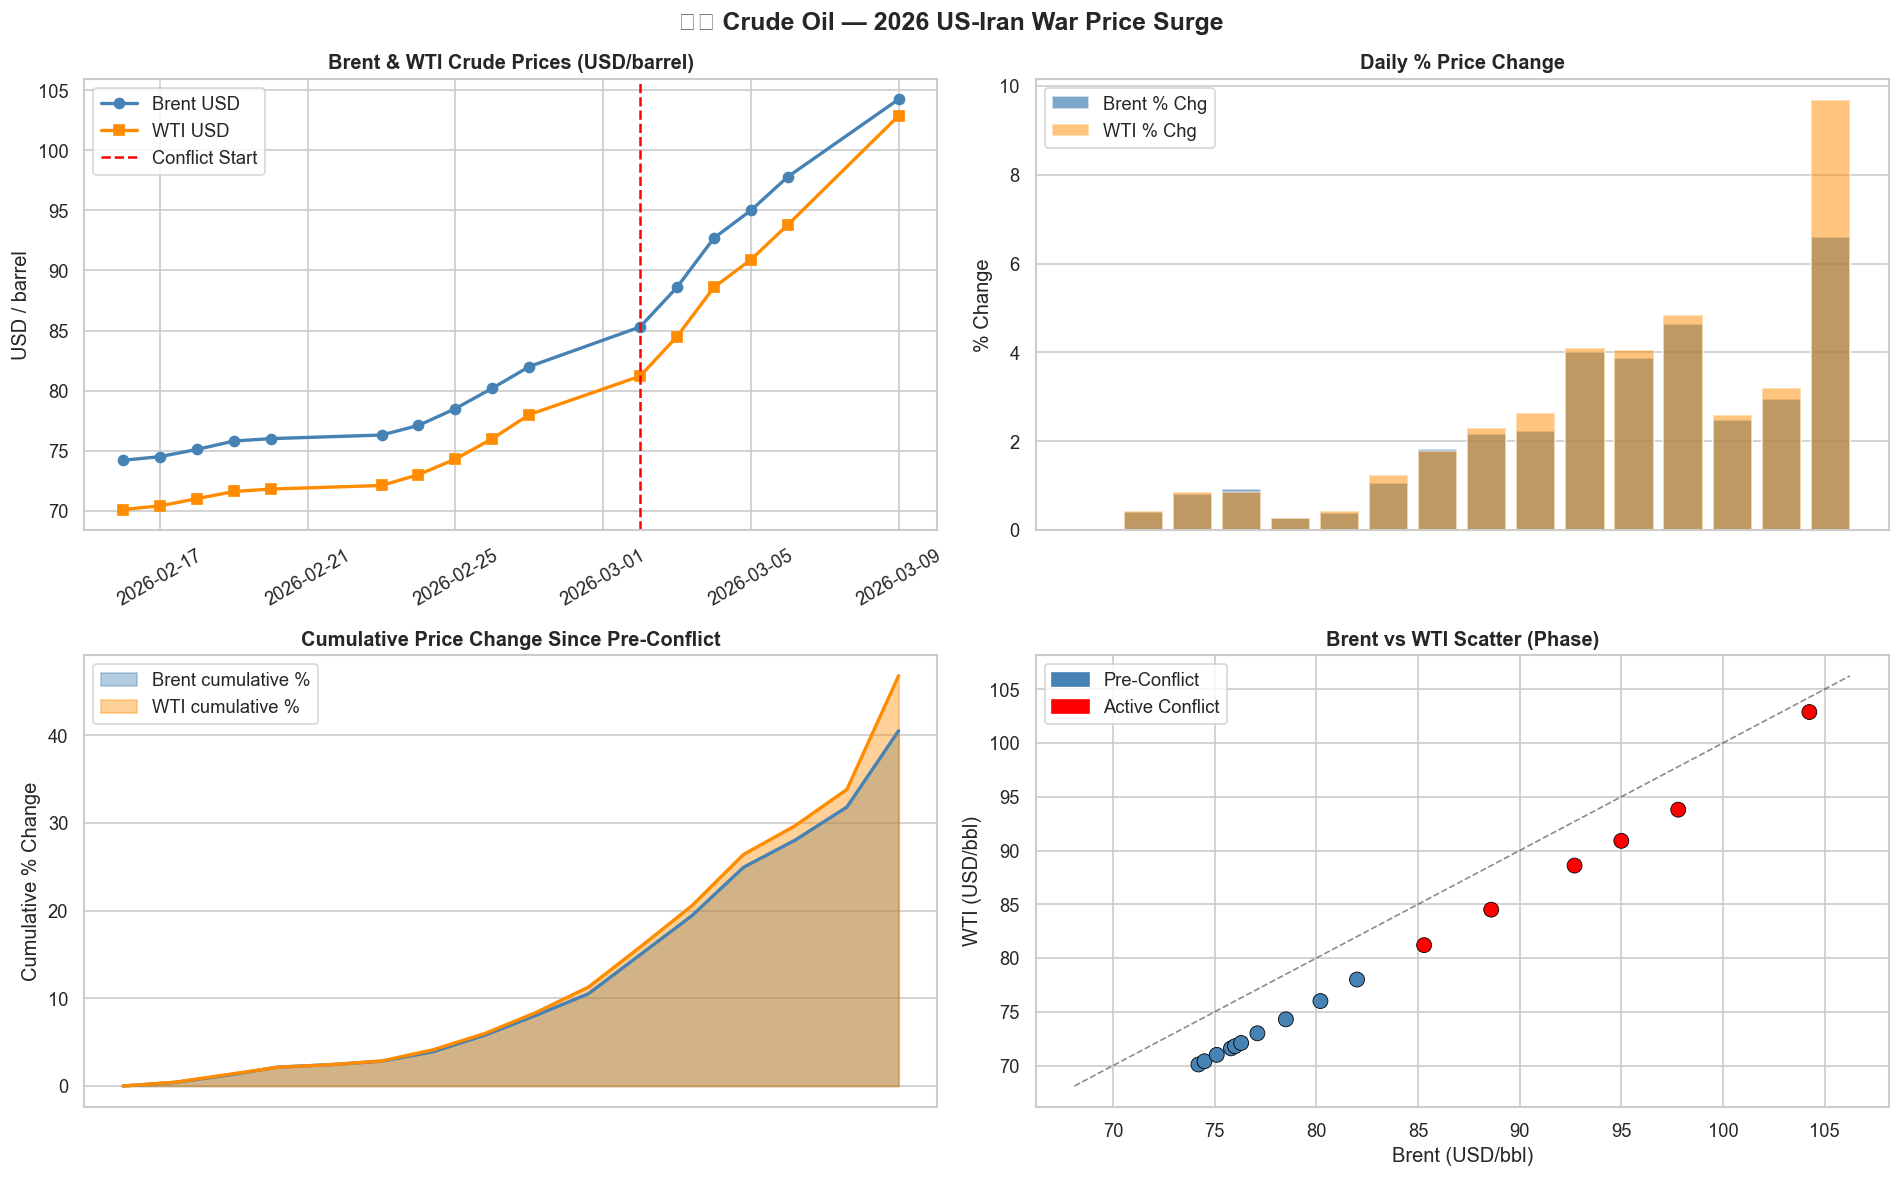


📊 Key Stats:
   Brent start  : $74.20
   Brent peak   : $104.25
   Total surge  : +40.5%


In [10]:
if df_crude_c is not None:
    dc = df_crude_c.copy()
    # Ensure Date column
    date_col = [c for c in dc.columns if 'date' in c.lower()]
    if date_col:
        dc = dc.sort_values(date_col[0])
        dates = dc[date_col[0]]
    else:
        dates = range(len(dc))

    brent_col = [c for c in dc.columns if 'brent' in c.lower() and 'usd' in c.lower()]
    wti_col   = [c for c in dc.columns if 'wti'   in c.lower() and 'usd' in c.lower()]
    phase_col = [c for c in dc.columns if 'phase' in c.lower()]

    if brent_col and wti_col:
        bc, wc = brent_col[0], wti_col[0]
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle('🛢️ Crude Oil — 2026 US-Iran War Price Surge', fontsize=15, fontweight='bold')

        # Plot 1: Brent & WTI prices
        ax = axes[0, 0]
        ax.plot(dates, dc[bc], 'o-', color='steelblue',  label='Brent USD', lw=2, ms=6)
        ax.plot(dates, dc[wc], 's-', color='darkorange', label='WTI USD',   lw=2, ms=6)
        if phase_col:
            pc = phase_col[0]
            conflict_start = dc[dc[pc].str.contains('Active', na=False)][date_col[0]].min()
            ax.axvline(conflict_start, color='red', ls='--', lw=1.5, label='Conflict Start')
        ax.set_title('Brent & WTI Crude Prices (USD/barrel)', fontweight='bold')
        ax.set_ylabel('USD / barrel')
        ax.legend(); ax.tick_params(axis='x', rotation=30)

        # Plot 2: % Daily Change
        ax = axes[0, 1]
        brent_chg = [c for c in dc.columns if 'brent' in c.lower() and 'pct' in c.lower()]
        wti_chg   = [c for c in dc.columns if 'wti'   in c.lower() and 'pct' in c.lower()]
        if brent_chg and wti_chg:
            ax.bar(range(len(dc)), dc[brent_chg[0]], color='steelblue',  alpha=0.7, label='Brent % Chg')
            ax.bar(range(len(dc)), dc[wti_chg[0]],   color='darkorange', alpha=0.5, label='WTI % Chg')
            ax.set_title('Daily % Price Change', fontweight='bold')
            ax.set_ylabel('% Change'); ax.legend()
            ax.set_xticks([]); ax.axhline(0, color='black', lw=0.8)

        # Plot 3: Cumulative returns
        ax = axes[1, 0]
        cum_brent = ((dc[bc] / dc[bc].iloc[0]) - 1) * 100
        cum_wti   = ((dc[wc] / dc[wc].iloc[0]) - 1) * 100
        ax.fill_between(range(len(dc)), cum_brent, alpha=0.4, color='steelblue', label='Brent cumulative %')
        ax.fill_between(range(len(dc)), cum_wti,   alpha=0.4, color='darkorange', label='WTI cumulative %')
        ax.plot(range(len(dc)), cum_brent, color='steelblue', lw=2)
        ax.plot(range(len(dc)), cum_wti,   color='darkorange', lw=2)
        ax.set_title('Cumulative Price Change Since Pre-Conflict', fontweight='bold')
        ax.set_ylabel('Cumulative % Change'); ax.legend(); ax.set_xticks([])

        # Plot 4: Brent vs WTI scatter
        ax = axes[1, 1]
        color_map = {'Pre-Conflict': 'steelblue', 'Active Conflict': 'red'}
        if phase_col:
            colors = dc[phase_col[0]].map(color_map).fillna('gray')
            ax.scatter(dc[bc], dc[wc], c=colors, s=80, edgecolors='black', lw=0.5, zorder=5)
            patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
            ax.legend(handles=patches)
        else:
            ax.scatter(dc[bc], dc[wc], color='steelblue', s=80)
        mn = min(dc[bc].min(), dc[wc].min()) - 2
        mx = max(dc[bc].max(), dc[wc].max()) + 2
        ax.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5, label='y=x')
        ax.set_xlabel('Brent (USD/bbl)'); ax.set_ylabel('WTI (USD/bbl)')
        ax.set_title('Brent vs WTI Scatter (Phase)', fontweight='bold')

        plt.tight_layout(); plt.show()

        brent_max = dc[bc].max(); brent_min = dc[bc].iloc[0]
        print(f"\n📊 Key Stats:")
        print(f"   Brent start  : ${brent_min:.2f}")
        print(f"   Brent peak   : ${brent_max:.2f}")
        print(f"   Total surge  : +{(brent_max/brent_min - 1)*100:.1f}%")
    else:
        print("⚠️  Brent/WTI columns not found — check column names")
else:
    print("⚠️  Crude oil DataFrame not available")

Columns: ['Country', 'ISO', 'Region', 'Currency', 'Before_War_Price', 'Mar7_Price', 'Unit', 'Amount_Change', 'Pct_Increase', 'Trend', 'Before_War_USD', 'Mar7_USD', 'Oil_Import_Dep']
Detected → country:Country, pct:Pct_Increase, before_usd:Before_War_USD, after_usd:Mar7_USD


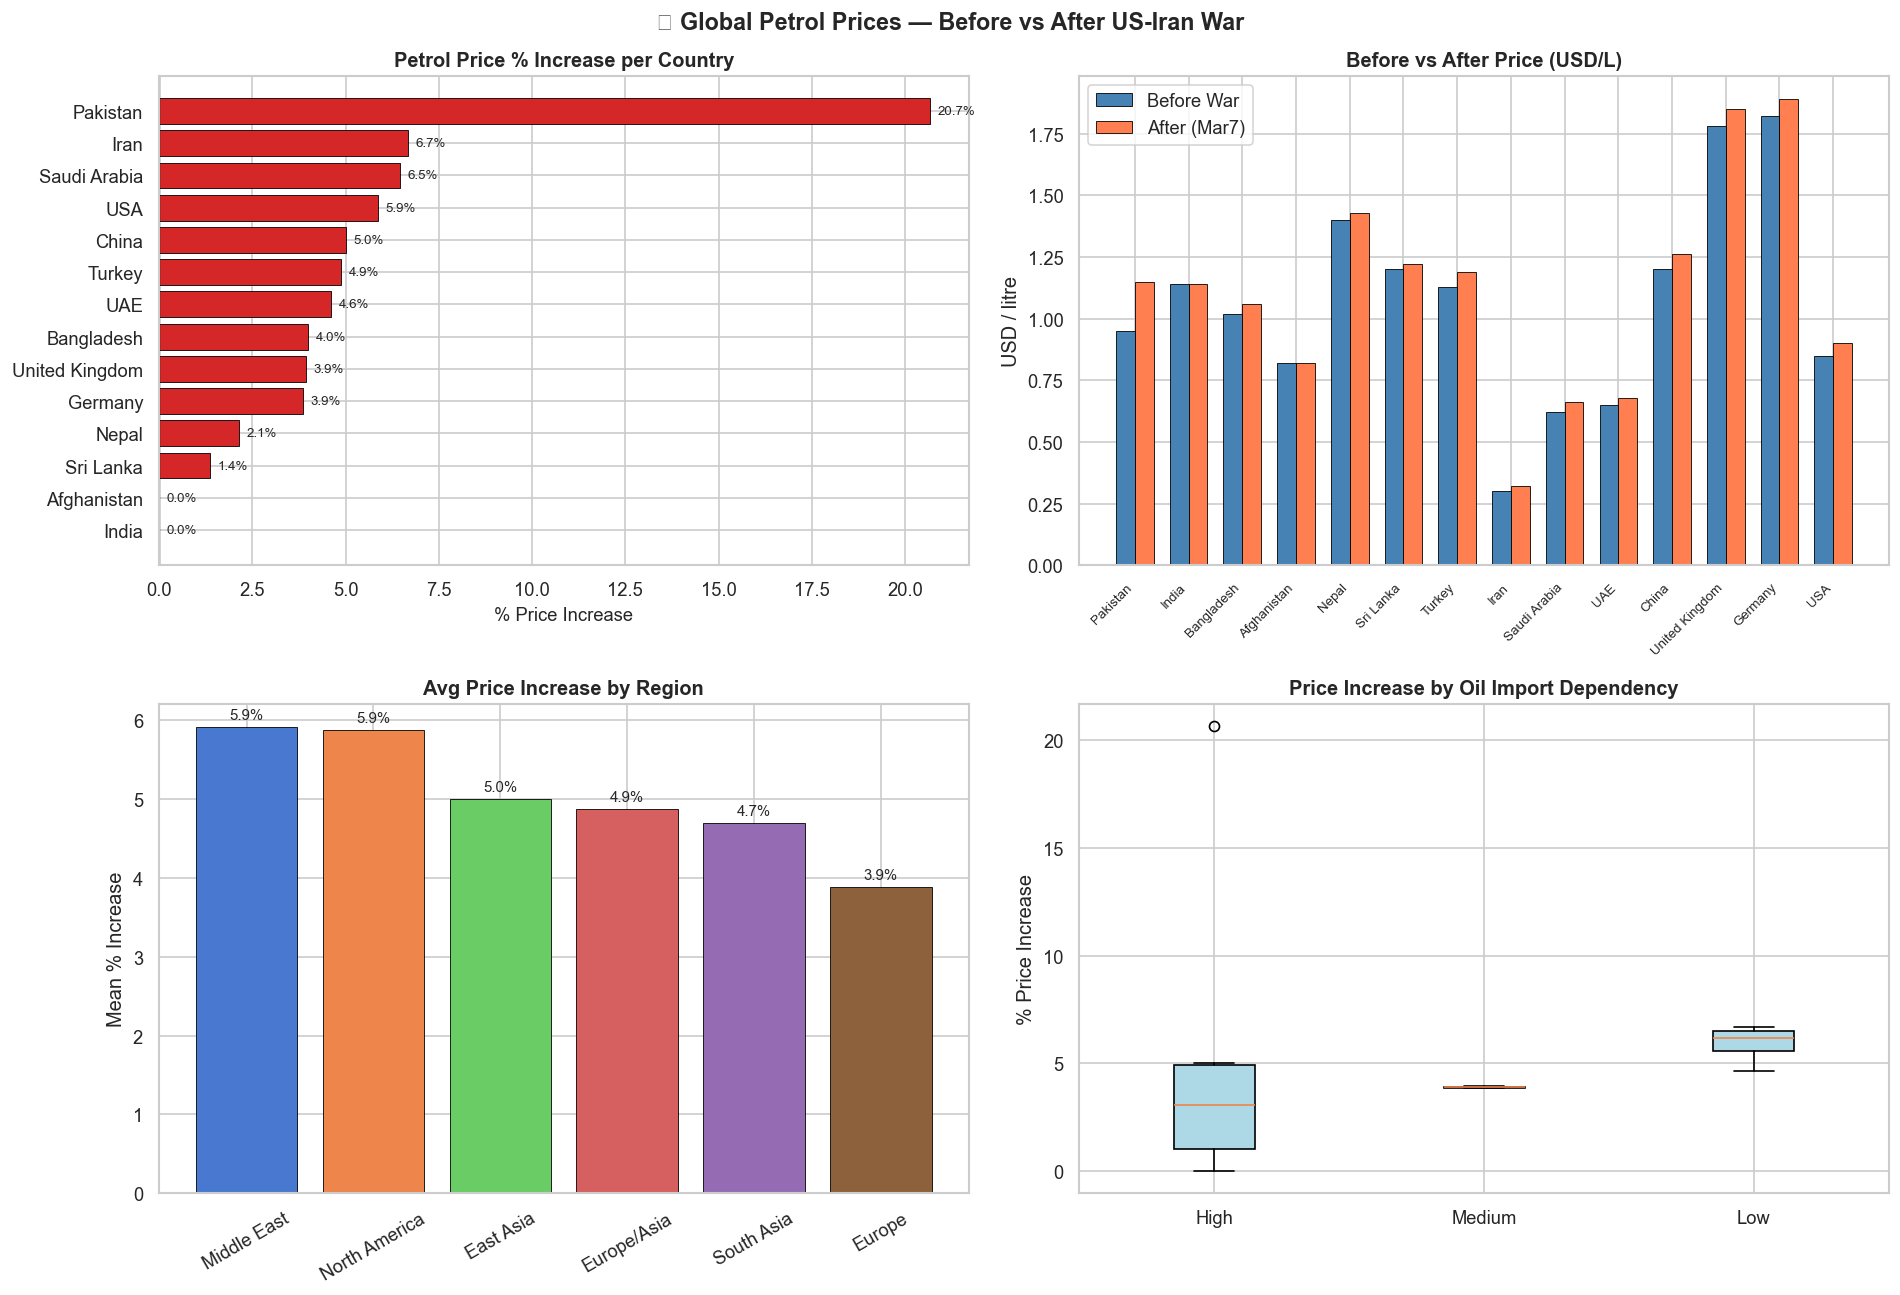


🏆 Highest increase: Pakistan (+20.66%)


In [11]:
if df_petrol_c is not None:
    dp = df_petrol_c.copy()
    print("Columns:", dp.columns.tolist())

    # Detect key columns robustly
    country_col  = next((c for c in dp.columns if 'country' in c.lower()), None)
    pct_col      = next((c for c in dp.columns if 'pct' in c.lower()), None)
    before_usd   = next((c for c in dp.columns if 'before' in c.lower() and 'usd' in c.lower()), None)
    after_usd    = next((c for c in dp.columns if ('mar7' in c.lower() or 'after' in c.lower()) and 'usd' in c.lower()), None)
    region_col   = next((c for c in dp.columns if 'region' in c.lower()), None)
    import_dep   = next((c for c in dp.columns if 'import' in c.lower() or 'dep' in c.lower()), None)

    print(f"Detected → country:{country_col}, pct:{pct_col}, before_usd:{before_usd}, after_usd:{after_usd}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('⛽ Global Petrol Prices — Before vs After US-Iran War', fontsize=14, fontweight='bold')

    if country_col and pct_col:
        # Plot 1: % Increase horizontal bar
        ax = axes[0, 0]
        dp_sorted = dp.sort_values(pct_col, ascending=True)
        colors = ['#d62728' if v > 0 else '#2ca02c' for v in dp_sorted[pct_col]]
        ax.barh(dp_sorted[country_col], dp_sorted[pct_col], color=colors, edgecolor='black', lw=0.5)
        ax.set_xlabel('% Price Increase', fontsize=11)
        ax.set_title('Petrol Price % Increase per Country', fontweight='bold')
        ax.axvline(0, color='black', lw=0.8)
        for i, (v, name) in enumerate(zip(dp_sorted[pct_col], dp_sorted[country_col])):
            ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)

    if country_col and before_usd and after_usd:
        # Plot 2: Before vs After USD
        ax = axes[0, 1]
        x = range(len(dp))
        w = 0.35
        ax.bar([i - w/2 for i in x], dp[before_usd], width=w, color='steelblue',  label='Before War',  edgecolor='black', lw=0.5)
        ax.bar([i + w/2 for i in x], dp[after_usd],  width=w, color='coral',      label='After (Mar7)',edgecolor='black', lw=0.5)
        ax.set_xticks(list(x)); ax.set_xticklabels(dp[country_col], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('USD / litre'); ax.set_title('Before vs After Price (USD/L)', fontweight='bold')
        ax.legend()

    if region_col and pct_col:
        # Plot 3: % Increase by Region
        ax = axes[1, 0]
        reg_grp = dp.groupby(region_col)[pct_col].mean().sort_values(ascending=False)
        palette = sns.color_palette('muted', len(reg_grp))
        ax.bar(reg_grp.index, reg_grp.values, color=palette, edgecolor='black', lw=0.5)
        ax.set_ylabel('Mean % Increase'); ax.set_title('Avg Price Increase by Region', fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
        for i, v in enumerate(reg_grp.values):
            ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

    if import_dep and pct_col:
        # Plot 4: Box by import dependency
        ax = axes[1, 1]
        dep_order = ['High', 'Medium', 'Low']
        valid = [d for d in dep_order if d in dp[import_dep].values]
        data_box = [dp[dp[import_dep] == d][pct_col].values for d in valid]
        bp = ax.boxplot(data_box, labels=valid, patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        ax.set_ylabel('% Price Increase'); ax.set_title('Price Increase by Oil Import Dependency', fontweight='bold')

    plt.tight_layout(); plt.show()
    if pct_col and country_col:
        max_row = dp.loc[dp[pct_col].idxmax()]
        print(f"\n🏆 Highest increase: {max_row[country_col]} (+{max_row[pct_col]:.2f}%)")
else:
    print("⚠️  Petrol prices DataFrame not available")

Columns: ['Country', 'Region', 'Oil_Import_Pct', 'GDP_Impact_Pct', 'Inflation_Risk', 'Stock_Market_Change', 'Currency_Pressure', 'Policy_Response', 'Vulnerability', 'Population_M']


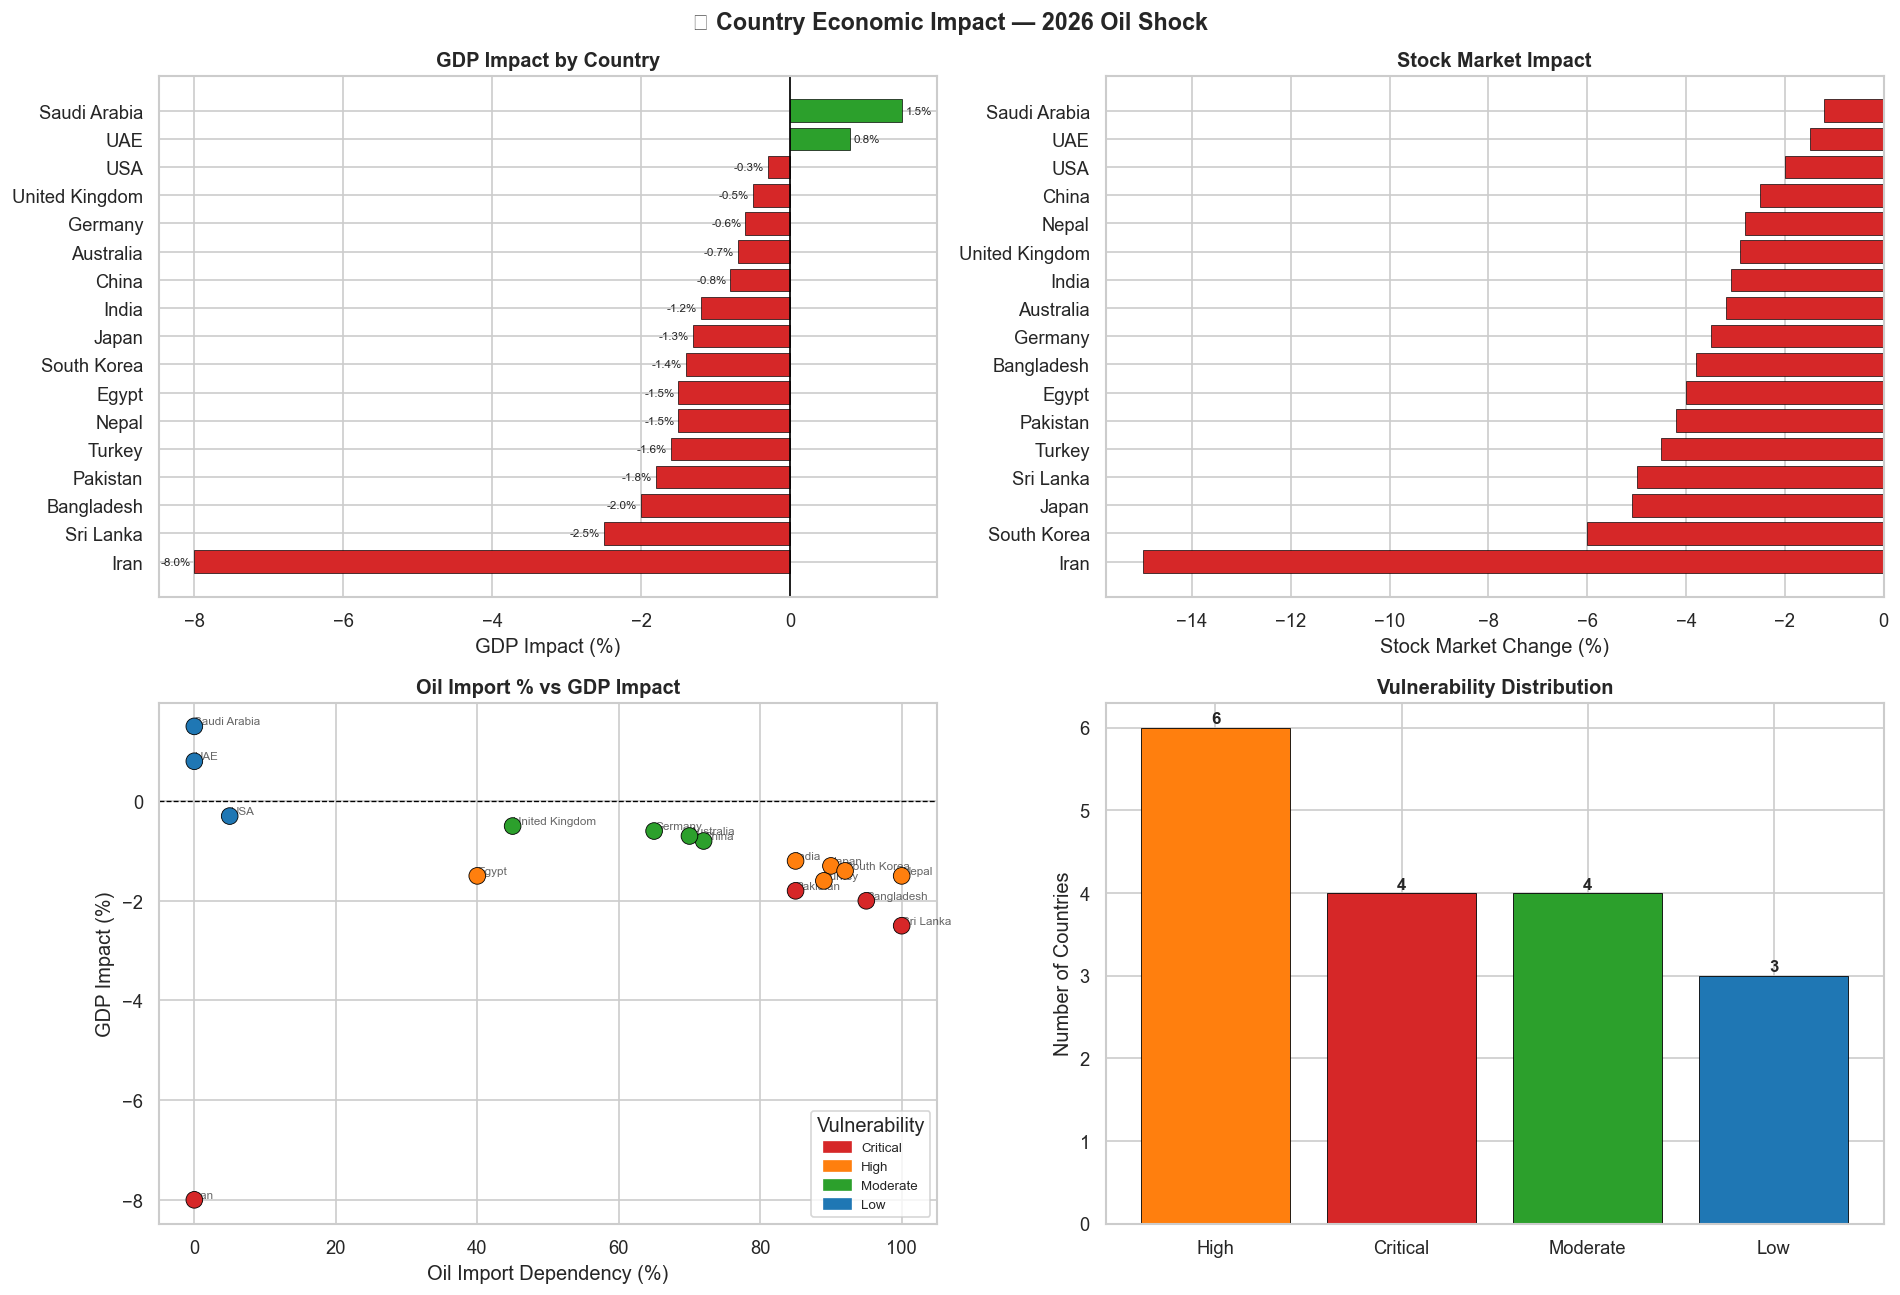

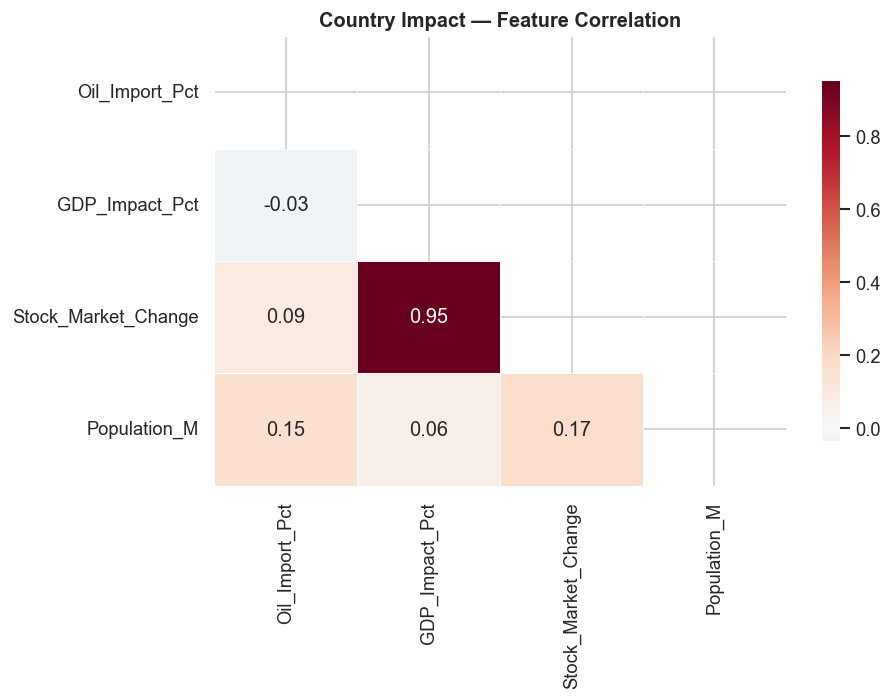

In [12]:
if df_country_c is not None:
    dc = df_country_c.copy()
    print("Columns:", dc.columns.tolist())

    gdp_col    = next((c for c in dc.columns if 'gdp' in c.lower()), None)
    stock_col  = next((c for c in dc.columns if 'stock' in c.lower()), None)
    import_col = next((c for c in dc.columns if 'import' in c.lower()), None)
    ctry_col   = next((c for c in dc.columns if 'country' in c.lower()), None)
    vuln_col   = next((c for c in dc.columns if 'vulnerab' in c.lower()), None)
    region_col = next((c for c in dc.columns if 'region' in c.lower()), None)

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('🌍 Country Economic Impact — 2026 Oil Shock', fontsize=14, fontweight='bold')

    # GDP Impact
    if gdp_col and ctry_col:
        ax = axes[0, 0]
        ds = dc.sort_values(gdp_col)
        colors = ['#d62728' if v < 0 else '#2ca02c' for v in ds[gdp_col]]
        ax.barh(ds[ctry_col], ds[gdp_col], color=colors, edgecolor='black', lw=0.4)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('GDP Impact (%)'); ax.set_title('GDP Impact by Country', fontweight='bold')
        for i, v in enumerate(ds[gdp_col]):
            ax.text(v + (0.05 if v >= 0 else -0.05), i, f'{v:.1f}%', va='center',
                    ha='left' if v >= 0 else 'right', fontsize=7)

    # Stock Market Impact
    if stock_col and ctry_col:
        ax = axes[0, 1]
        ds2 = dc.sort_values(stock_col)
        colors2 = ['#d62728' if v < 0 else '#2ca02c' for v in ds2[stock_col]]
        ax.barh(ds2[ctry_col], ds2[stock_col], color=colors2, edgecolor='black', lw=0.4)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('Stock Market Change (%)'); ax.set_title('Stock Market Impact', fontweight='bold')

    # Import vs GDP scatter
    if import_col and gdp_col:
        ax = axes[1, 0]
        vuln_colors = {'Critical': '#d62728', 'High': '#ff7f0e',
                       'Moderate': '#2ca02c', 'Low': '#1f77b4'}
        if vuln_col:
            c_vals = dc[vuln_col].map(vuln_colors).fillna('gray')
            scatter = ax.scatter(dc[import_col], dc[gdp_col], c=c_vals, s=100,
                                 edgecolors='black', lw=0.5, zorder=5)
            patches = [mpatches.Patch(color=v, label=k) for k, v in vuln_colors.items()
                       if k in dc[vuln_col].values]
            ax.legend(handles=patches, fontsize=8, title='Vulnerability')
        else:
            ax.scatter(dc[import_col], dc[gdp_col], color='steelblue', s=80)
        if ctry_col:
            for _, row in dc.iterrows():
                ax.annotate(row[ctry_col], (row[import_col], row[gdp_col]),
                            fontsize=7, ha='left', va='bottom', alpha=0.7)
        ax.set_xlabel('Oil Import Dependency (%)'); ax.set_ylabel('GDP Impact (%)')
        ax.set_title('Oil Import % vs GDP Impact', fontweight='bold')
        ax.axhline(0, color='black', lw=0.8, ls='--')

    # Vulnerability distribution
    if vuln_col:
        ax = axes[1, 1]
        vc = dc[vuln_col].value_counts()
        palette = [vuln_colors.get(k, 'gray') for k in vc.index]
        ax.bar(vc.index, vc.values, color=palette, edgecolor='black', lw=0.5)
        ax.set_ylabel('Number of Countries'); ax.set_title('Vulnerability Distribution', fontweight='bold')
        for i, v in enumerate(vc.values):
            ax.text(i, v + 0.05, str(v), ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout(); plt.show()

    # Correlation heatmap
    num_cols_ci = dc.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols_ci) >= 2:
        plt.figure(figsize=(8, 6))
        corr = dc[num_cols_ci].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
        plt.title('Country Impact — Feature Correlation', fontweight='bold')
        plt.tight_layout(); plt.show()
else:
    print("⚠️  Country impact DataFrame not available")

Columns: ['Date', 'Event', 'Description', 'Location', 'Category']


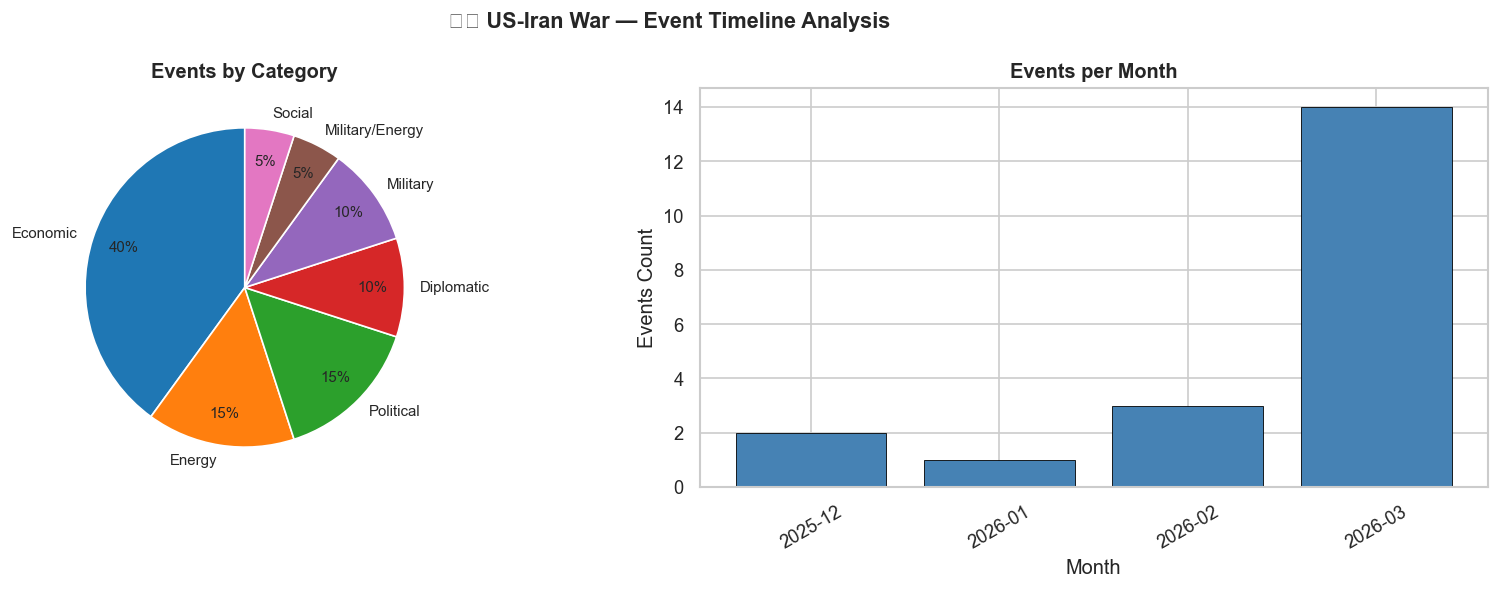


📋 Full Timeline:


"      Date                   Event                                                                             Description         Location        Category\n2025-12-01                Protests       Widespread economic protests erupt across Iran — soaring prices & plummeting rial             Iran       Political\n2025-12-15       Internet Shutdown                          Iran government shuts down internet amid crackdown on protests             Iran       Political\n2026-01-10     US Military Buildup         US bolsters military presence off Iran's coast; Trump says 'help is on the way'       USA / Iran        Military\n2026-02-01      Geneva Talks Begin                 Indirect US-Iran nuclear negotiations begin in Geneva, mediated by Oman      Switzerland      Diplomatic\n2026-02-25          Talks Collapse                                    Geneva nuclear negotiations end without breakthrough      Switzerland      Diplomatic\n2026-02-28  Military Strikes Begin US-Israeli military st

In [13]:
if df_timeline_c is not None:
    dt = df_timeline_c.copy()
    print("Columns:", dt.columns.tolist())

    cat_col  = next((c for c in dt.columns if 'categ' in c.lower()), None)
    date_col = next((c for c in dt.columns if 'date' in c.lower()), None)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('⏱️ US-Iran War — Event Timeline Analysis', fontsize=13, fontweight='bold')

    # Category counts
    if cat_col:
        ax = axes[0]
        cc = dt[cat_col].value_counts()
        palette = sns.color_palette('tab10', len(cc))
        wedges, texts, autotexts = ax.pie(cc.values, labels=cc.index, autopct='%1.0f%%',
                                           colors=palette, startangle=90,
                                           pctdistance=0.8, textprops={'fontsize': 9})
        ax.set_title('Events by Category', fontweight='bold')

    # Events over time
    if date_col:
        ax = axes[1]
        if hasattr(dt[date_col], 'dt'):
            dt['month_year'] = dt[date_col].dt.to_period('M').astype(str)
        else:
            dt['month_year'] = dt[date_col].astype(str).str[:7]
        mc = dt['month_year'].value_counts().sort_index()
        ax.bar(mc.index, mc.values, color='steelblue', edgecolor='black', lw=0.5)
        ax.set_xlabel('Month'); ax.set_ylabel('Events Count')
        ax.set_title('Events per Month', fontweight='bold')
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout(); plt.show()

    print("\n📋 Full Timeline:")
    disp_cols = [c for c in dt.columns if c not in ['month_year']]
    display(dt[disp_cols].to_string(index=False))
else:
    print("⚠️  Timeline DataFrame not available")

Columns: ['Category', 'Type', 'Title', 'Description', 'Impact_Level', 'Affected', 'Source']


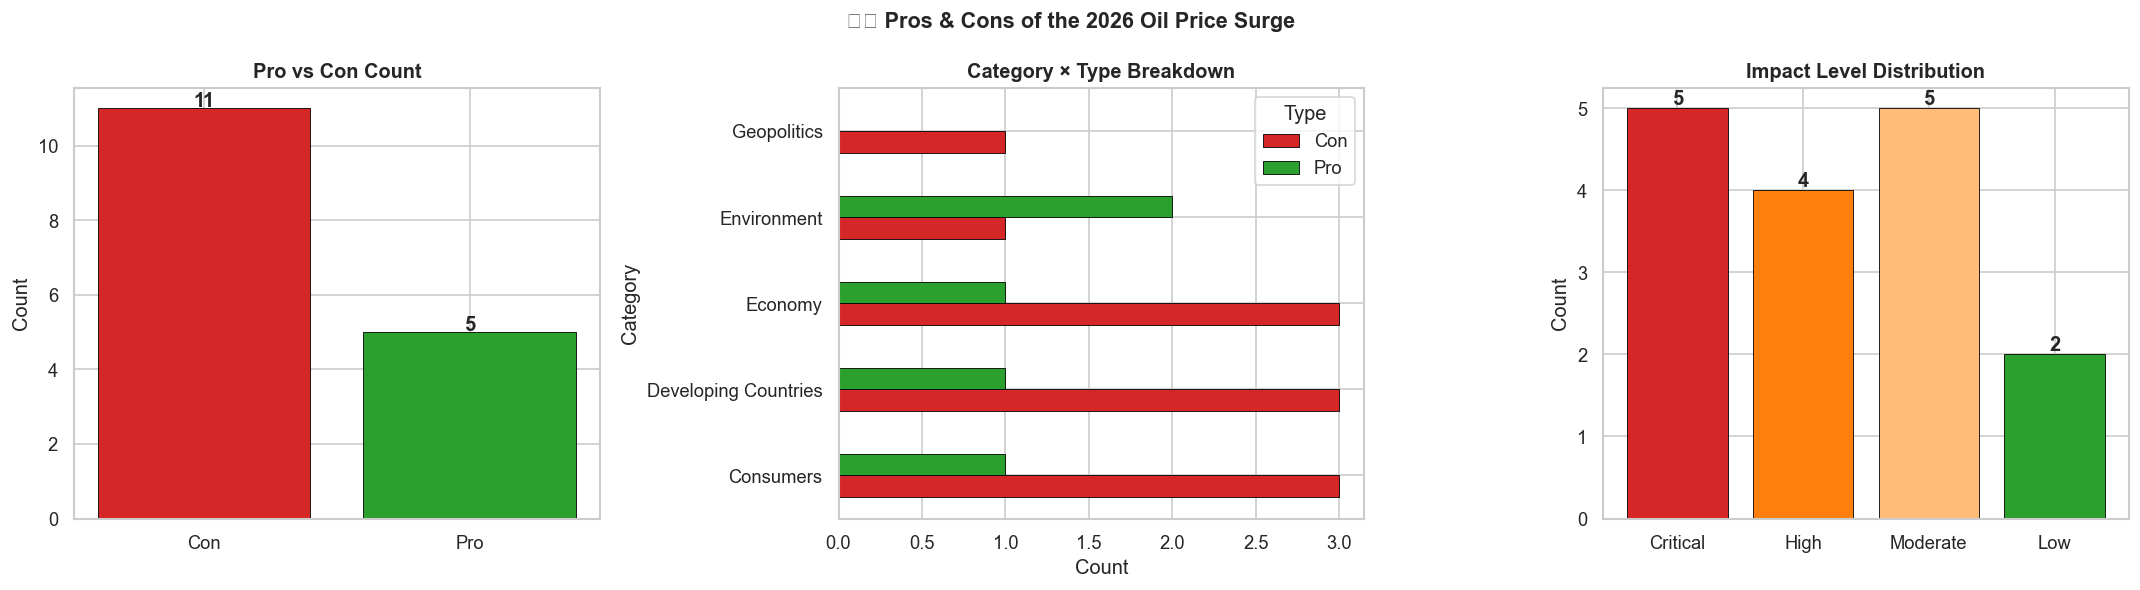


🔴 CRITICAL CONS:
  ❌ Stagflation Risk
  ❌ Reduced Purchasing Power
  ❌ Balance of Payments Crisis
  ❌ Poverty Increase
  ❌ Regional Destabilization

🟢 NOTABLE PROS:
  ✅ Oil Exporter Windfall
  ✅ Accelerated Green Transition
  ✅ Reduced Consumption
  ✅ Long-term EV Adoption
  ✅ Diversification Push


In [14]:
if df_proscons_c is not None:
    dpc = df_proscons_c.copy()
    print("Columns:", dpc.columns.tolist())

    type_col  = next((c for c in dpc.columns if 'type' in c.lower()), None)
    cat_col   = next((c for c in dpc.columns if 'categ' in c.lower()), None)
    impact_col= next((c for c in dpc.columns if 'impact' in c.lower()), None)
    title_col = next((c for c in dpc.columns if 'title' in c.lower()), None)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('✅❌ Pros & Cons of the 2026 Oil Price Surge', fontsize=13, fontweight='bold')

    # Pro/Con split
    if type_col:
        ax = axes[0]
        tc = dpc[type_col].value_counts()
        colors_pc = {'Pro': '#2ca02c', 'Con': '#d62728'}
        c_vals = [colors_pc.get(k, 'steelblue') for k in tc.index]
        ax.bar(tc.index, tc.values, color=c_vals, edgecolor='black', lw=0.5)
        ax.set_ylabel('Count'); ax.set_title('Pro vs Con Count', fontweight='bold')
        for i, v in enumerate(tc.values):
            ax.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # Category breakdown
    if cat_col and type_col:
        ax = axes[1]
        ct = pd.crosstab(dpc[cat_col], dpc[type_col])
        ct.plot(kind='barh', ax=ax, color=['#d62728', '#2ca02c'][:len(ct.columns)],
                edgecolor='black', lw=0.5)
        ax.set_title('Category × Type Breakdown', fontweight='bold')
        ax.set_xlabel('Count'); ax.legend(title='Type')

    # Impact level
    if impact_col:
        ax = axes[2]
        impact_order = ['Critical', 'High', 'Moderate', 'Low']
        il = dpc[impact_col].value_counts()
        il = il.reindex([i for i in impact_order if i in il.index])
        impact_colors = {'Critical': '#d62728', 'High': '#ff7f0e',
                         'Moderate': '#ffbb78', 'Low': '#2ca02c'}
        c_vals = [impact_colors.get(k, 'steelblue') for k in il.index]
        ax.bar(il.index, il.values, color=c_vals, edgecolor='black', lw=0.5)
        ax.set_ylabel('Count'); ax.set_title('Impact Level Distribution', fontweight='bold')
        for i, v in enumerate(il.values):
            ax.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    plt.tight_layout(); plt.show()

    # Summary table
    if type_col and title_col and impact_col:
        print("\n🔴 CRITICAL CONS:")
        crit_cons = dpc[(dpc[type_col] == 'Con') & (dpc[impact_col] == 'Critical')]
        if len(crit_cons):
            for _, r in crit_cons.iterrows():
                print(f"  ❌ {r[title_col]}")
        print("\n🟢 NOTABLE PROS:")
        pros = dpc[dpc[type_col] == 'Pro']
        if len(pros):
            for _, r in pros.iterrows():
                print(f"  ✅ {r[title_col]}")
else:
    print("⚠️  Pros/Cons DataFrame not available")

In [15]:
# ──────────────────────────────────────────────────────────────────────
# We will train on: petrol_prices (14 rows, regression target = Pct_Increase)
# AND on country_impact (17 rows).
# For a richer dataset we MERGE them where Country matches.
# ──────────────────────────────────────────────────────────────────────

def safe_divide(num, denom, fill=0):
    r = num / (denom + 1e-10)
    if hasattr(r, 'replace'): r = r.replace([np.inf, -np.inf], fill).fillna(fill)
    return r

def safe_log(vals, fill=0):
    r = np.log1p(np.maximum(vals, 0))
    if hasattr(r, 'replace'): r = r.replace([np.inf, -np.inf], fill).fillna(fill)
    return r

# ── Build merged feature table ─────────────────────────────────────────
if df_petrol_c is not None and df_country_c is not None:
    # Standardise country column name
    for _df in [df_petrol_c, df_country_c]:
        _df.columns = [c.strip() for c in _df.columns]

    ctry_p = next((c for c in df_petrol_c.columns if 'country' in c.lower()), None)
    ctry_c = next((c for c in df_country_c.columns if 'country' in c.lower()), None)

    if ctry_p and ctry_c:
        df_merged = df_petrol_c.merge(
            df_country_c, left_on=ctry_p, right_on=ctry_c, how='left',
            suffixes=('_petrol', '_country')
        )
        print(f"✅ Merged shape: {df_merged.shape}")
    else:
        df_merged = df_petrol_c.copy()
        print("⚠️  Could not merge — using petrol table only")

    # ── Encode categoricals ────────────────────────────────────────────
    le_dict = {}
    for col in df_merged.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df_merged[col] = le.fit_transform(df_merged[col].astype(str))
        le_dict[col] = le
        print(f"  ✅ LabelEncoded: {col}")

    # ── Drop remaining datetime / unhelpful cols ──────────────────────
    drop_dt = df_merged.select_dtypes(include=['datetime64']).columns.tolist()
    if drop_dt:
        df_merged.drop(columns=drop_dt, inplace=True)
        print(f"  ✅ Dropped datetime: {drop_dt}")

    # ── Identify TARGET ───────────────────────────────────────────────
    TARGET = None
    for candidate in ['Pct_Increase', 'pct_increase', 'PctIncrease']:
        if candidate in df_merged.columns:
            TARGET = candidate; break
    if TARGET is None:
        # Fallback: first column with 'pct' in name
        pct_cands = [c for c in df_merged.columns if 'pct' in c.lower()]
        TARGET = pct_cands[0] if pct_cands else df_merged.select_dtypes(include=[np.number]).columns[-1]

    print(f"\n🎯 Target column: '{TARGET}'")

    # ── Engineered features ───────────────────────────────────────────
    num_base = df_merged.select_dtypes(include=[np.number]).columns.tolist()
    num_base = [c for c in num_base if c != TARGET]

    # Ratio: after_usd / before_usd  (price multiplier)
    before_usd = next((c for c in df_merged.columns if 'before' in c.lower() and 'usd' in c.lower()), None)
    after_usd  = next((c for c in df_merged.columns if ('mar7' in c.lower() or 'after' in c.lower()) and 'usd' in c.lower()), None)
    if before_usd and after_usd:
        df_merged['price_multiplier'] = safe_divide(df_merged[after_usd], df_merged[before_usd])
        print("✅ Engineered: price_multiplier")

    # Log of before_usd price
    if before_usd:
        df_merged['log_before_usd'] = safe_log(df_merged[before_usd])
        print("✅ Engineered: log_before_usd")

    # GDP × import dependency interaction
    gdp_col    = next((c for c in df_merged.columns if 'gdp' in c.lower()), None)
    import_col = next((c for c in df_merged.columns if 'oil_import' in c.lower() or 'import_pct' in c.lower()), None)
    if gdp_col and import_col:
        df_merged['gdp_import_interact'] = df_merged[gdp_col] * df_merged[import_col]
        print("✅ Engineered: gdp_import_interact")

    stock_col = next((c for c in df_merged.columns if 'stock' in c.lower()), None)
    if stock_col and import_col:
        df_merged['stock_import_ratio'] = safe_divide(df_merged[stock_col], df_merged[import_col])
        print("✅ Engineered: stock_import_ratio")

    print(f"\n✅ Final merged shape: {df_merged.shape}")
    print(f"   Total features available: {df_merged.shape[1] - 1}")

elif df_petrol_c is not None:
    df_merged = df_petrol_c.copy()
    for col in df_merged.select_dtypes(include=['object']).columns:
        df_merged[col] = LabelEncoder().fit_transform(df_merged[col].astype(str))
    pct_cands = [c for c in df_merged.columns if 'pct' in c.lower()]
    TARGET = pct_cands[0] if pct_cands else df_merged.select_dtypes(include=[np.number]).columns[-1]
    print(f"⚠️  Using petrol-only table. Target: {TARGET}")
else:
    raise RuntimeError("❌ No suitable DataFrame for ML!")

print(f"\n🎯 TARGET = '{TARGET}'")

✅ Merged shape: (14, 22)
  ✅ LabelEncoded: Country
  ✅ LabelEncoded: ISO
  ✅ LabelEncoded: Region_petrol
  ✅ LabelEncoded: Currency
  ✅ LabelEncoded: Unit
  ✅ LabelEncoded: Trend
  ✅ LabelEncoded: Oil_Import_Dep
  ✅ LabelEncoded: Region_country
  ✅ LabelEncoded: Inflation_Risk
  ✅ LabelEncoded: Currency_Pressure
  ✅ LabelEncoded: Policy_Response
  ✅ LabelEncoded: Vulnerability

🎯 Target column: 'Pct_Increase'
✅ Engineered: price_multiplier
✅ Engineered: log_before_usd
✅ Engineered: gdp_import_interact
✅ Engineered: stock_import_ratio

✅ Final merged shape: (14, 26)
   Total features available: 25

🎯 TARGET = 'Pct_Increase'


In [16]:
# ── Select features ──────────────────────────────────────────────────
# Exclude target + potential leakage columns (amount_change, etc.)
LEAKAGE_KEYWORDS = ['amount_change', 'pct_increase', TARGET.lower(),
                    'mar7_price', 'after_price']  # add more if needed

feature_cols = [
    c for c in df_merged.select_dtypes(include=[np.number]).columns
    if c != TARGET
    and not any(kw in c.lower() for kw in LEAKAGE_KEYWORDS)
]

print(f"Feature columns ({len(feature_cols)}):")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

X = df_merged[feature_cols].copy()
y = df_merged[TARGET].copy()

print("\n" + "="*70)
print("🔍 PRE-MODELING QUALITY CHECKPOINT")
print("="*70)

# CHECK 1: Missing values
print("\nCHECK 1: Missing Values")
x_miss = X.isnull().sum().sum(); y_miss = y.isnull().sum()
if x_miss:
    for c in X.columns:
        if X[c].isnull().any():
            X[c].fillna(X[c].median(), inplace=True)
    x_miss = X.isnull().sum().sum()
if y_miss:
    y.fillna(y.median(), inplace=True)
    y_miss = y.isnull().sum()
assert x_miss == 0, f"❌ {x_miss} NaN in X"; assert y_miss == 0
print("✅ PASS: No missing values")

# CHECK 2: Infinite values
print("\nCHECK 2: Infinite Values")
inf_n = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
if inf_n:
    X = X.replace([np.inf, -np.inf], np.nan)
    for c in X.columns:
        if X[c].isnull().any(): X[c].fillna(X[c].median(), inplace=True)
    inf_n = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
assert inf_n == 0; print("✅ PASS: No infinite values")

# CHECK 3: All numeric
print("\nCHECK 3: Data Types")
nn = X.select_dtypes(exclude=[np.number]).columns.tolist()
if nn:
    for c in nn: X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0)
    print(f"  ✅ Converted {len(nn)} cols")
else:
    print("✅ PASS: All numeric")

# CHECK 4: Shapes
print("\nCHECK 4: Shape Consistency")
assert len(X) == len(y), f"❌ Mismatch!"
print(f"✅ PASS: X={X.shape}, y={y.shape}")

# CHECK 5: Target
print("\nCHECK 5: Target Distribution")
print(f"  Range [{y.min():.3f}, {y.max():.3f}]  Mean={y.mean():.3f}  Std={y.std():.3f}  Skew={y.skew():.3f}")
print("✅ PASS")

# CHECK 6: Dataset size note
print("\nCHECK 6: Dataset Size")
print(f"  Samples: {len(X)} — small dataset (geo/policy data); using LOO/5-fold CV carefully")
print("✅ PASS (small dataset — CV will be used instead of hold-out where needed)")

print("\n" + "="*70)
print("✅✅✅ ALL CHECKS PASSED — READY FOR MODELING ✅✅✅")
print("="*70)

Feature columns (23):
   1. Country
   2. ISO
   3. Region_petrol
   4. Currency
   5. Before_War_Price
   6. Unit
   7. Trend
   8. Before_War_USD
   9. Mar7_USD
  10. Oil_Import_Dep
  11. Region_country
  12. Oil_Import_Pct
  13. GDP_Impact_Pct
  14. Inflation_Risk
  15. Stock_Market_Change
  16. Currency_Pressure
  17. Policy_Response
  18. Vulnerability
  19. Population_M
  20. price_multiplier
  21. log_before_usd
  22. gdp_import_interact
  23. stock_import_ratio

🔍 PRE-MODELING QUALITY CHECKPOINT

CHECK 1: Missing Values
✅ PASS: No missing values

CHECK 2: Infinite Values
✅ PASS: No infinite values

CHECK 3: Data Types
✅ PASS: All numeric

CHECK 4: Shape Consistency
✅ PASS: X=(14, 23), y=(14,)

CHECK 5: Target Distribution
  Range [0.000, 20.660]  Mean=4.961  Std=5.006  Skew=2.548
✅ PASS

CHECK 6: Dataset Size
  Samples: 14 — small dataset (geo/policy data); using LOO/5-fold CV carefully
✅ PASS (small dataset — CV will be used instead of hold-out where needed)

✅✅✅ ALL CHECKS PA

In [17]:
# Small dataset → use smaller test split to keep enough training samples
TEST_SIZE = 0.2 if len(X) > 20 else 0.15

print(f"📊 Train-Test Split  (test_size={TEST_SIZE})")
print("-"*50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

assert len(X_train) == len(y_train)
assert len(X_test)  == len(y_test)

print(f"✅ Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")

# Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X), columns=X.columns, index=X.index
)
X_train_sc = X_scaled.loc[X_train.index]
X_test_sc  = X_scaled.loc[X_test.index]

assert X_train_sc.shape == X_train.shape
assert X_test_sc.shape  == X_test.shape
assert len(X_train_sc)  == len(y_train)
assert len(X_test_sc)   == len(y_test)

print(f"✅ Scaling complete: X_train_sc={X_train_sc.shape}, X_test_sc={X_test_sc.shape}")
print("✅ All alignment assertions passed")

📊 Train-Test Split  (test_size=0.15)
--------------------------------------------------
✅ Train: 11 samples  |  Test: 3 samples
✅ Scaling complete: X_train_sc=(11, 23), X_test_sc=(3, 23)
✅ All alignment assertions passed


In [18]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    print(f"\n{'='*65}")
    print(f"🔍 {name}")
    print(f"{'='*65}")
    try:
        model.fit(X_tr, y_tr)
        y_tr_p = model.predict(X_tr)
        y_te_p = model.predict(X_te)

        tr_r2   = r2_score(y_tr, y_tr_p)
        te_r2   = r2_score(y_te, y_te_p)
        tr_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_p))
        te_rmse = np.sqrt(mean_squared_error(y_te, y_te_p))
        tr_mae  = mean_absolute_error(y_tr, y_tr_p)
        te_mae  = mean_absolute_error(y_te, y_te_p)
        te_mape = np.mean(np.abs((y_te - y_te_p) / (np.abs(y_te) + 1e-10))) * 100

        print(f"{'Metric':<22} {'Train':<14} {'Test':<14}")
        print("-"*50)
        print(f"{'R²':<22} {tr_r2:<14.4f} {te_r2:<14.4f}")
        print(f"{'RMSE':<22} {tr_rmse:<14.4f} {te_rmse:<14.4f}")
        print(f"{'MAE':<22} {tr_mae:<14.4f} {te_mae:<14.4f}")
        print(f"{'MAPE (%)':<22} {'-':<14} {te_mape:<14.2f}")
        gap = abs(tr_r2 - te_r2)
        print(f"\nOverfitting gap: {gap:.4f}  {'✅ OK' if gap < 0.15 else '⚠️ Review'}")

        # CV — careful with very small datasets
        n_cv = min(5, len(X_tr))
        try:
            cv = cross_val_score(model, X_tr, y_tr, cv=n_cv, scoring='r2', n_jobs=-1)
            print(f"{n_cv}-Fold CV R²: {cv.mean():.4f} ± {cv.std():.4f}")
            cv_m, cv_s = cv.mean(), cv.std()
        except Exception as ce:
            print(f"⚠️  CV failed: {ce}"); cv_m = cv_s = None

        return dict(
            model_name=name, model=model, predictions=y_te_p,
            problem_type='Regression',
            train_r2=tr_r2, test_r2=te_r2,
            train_rmse=tr_rmse, test_rmse=te_rmse,
            train_mae=tr_mae, test_mae=te_mae,
            test_mape=te_mape, cv_mean=cv_m, cv_std=cv_s
        )
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"❌ {name} failed: {e}"); return None

In [19]:
# ── Model 1: Ridge (scaled) ────────────────────────────────────────────
try:
    ridge_res = evaluate_model(Ridge(alpha=1.0), X_train_sc, X_test_sc, y_train, y_test, 'Ridge Regression')
except Exception as e:
    print(f"❌ Ridge failed: {e}"); ridge_res = None

# ── Model 2: Lasso (scaled) ────────────────────────────────────────────
try:
    lasso_res = evaluate_model(Lasso(alpha=0.5, max_iter=10000), X_train_sc, X_test_sc, y_train, y_test, 'Lasso Regression')
except Exception as e:
    print(f"❌ Lasso failed: {e}"); lasso_res = None

# ── Model 3: Random Forest (raw features) ─────────────────────────────
try:
    rf_res = evaluate_model(
        RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1),
        X_train, X_test, y_train, y_test, 'Random Forest'
    )
except Exception as e:
    print(f"❌ RF failed: {e}"); rf_res = None

# ── Model 4: Gradient Boosting ─────────────────────────────────────────
try:
    gb_res = evaluate_model(
        GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE),
        X_train, X_test, y_train, y_test, 'Gradient Boosting'
    )
except Exception as e:
    print(f"❌ GB failed: {e}"); gb_res = None

# ── Model 5: XGBoost (optional) ───────────────────────────────────────
xgb_res = None
if XGB_OK:
    try:
        xgb_res = evaluate_model(
            XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                         random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
            X_train, X_test, y_train, y_test, 'XGBoost'
        )
    except Exception as e:
        print(f"❌ XGBoost failed: {e}"); xgb_res = None

# ── Model 6: LightGBM (optional) ──────────────────────────────────────
lgb_res = None
if LGB_OK:
    try:
        lgb_res = evaluate_model(
            LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                          random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1),
            X_train, X_test, y_train, y_test, 'LightGBM'
        )
    except Exception as e:
        print(f"❌ LightGBM failed: {e}"); lgb_res = None


🔍 Ridge Regression
Metric                 Train          Test          
--------------------------------------------------
R²                     0.9943         -0.4347       
RMSE                   0.1764         9.2578        
MAE                    0.1224         5.7698        
MAPE (%)               -              35.42         

Overfitting gap: 1.4289  ⚠️ Review
5-Fold CV R²: 0.4047 ± 0.5469

🔍 Lasso Regression
Metric                 Train          Test          
--------------------------------------------------
R²                     0.8500         -0.7018       
RMSE                   0.9010         10.0828       
MAE                    0.8737         6.4105        
MAPE (%)               -              42.35         

Overfitting gap: 1.5518  ⚠️ Review
5-Fold CV R²: 0.0175 ± 0.6910

🔍 Random Forest
Metric                 Train          Test          
--------------------------------------------------
R²                     0.9570         -0.5588       
RMSE                  

✅ Successful models: 5


,Model,Train R²,Test R²,Test RMSE,Test MAE,Test MAPE%,CV R²
3,Gradient Boosting,1.0000,-0.3400,8.9470,5.5700,34.07,0.5951
0,Ridge Regression,0.9943,-0.4347,9.2578,5.7698,35.42,0.4047
2,Random Forest,0.9570,-0.5588,9.6500,6.0827,38.82,0.1255
4,LightGBM,-0.0000,-0.6183,9.8324,6.0776,36.66,-2.3245
1,Lasso Regression,0.8500,-0.7018,10.0828,6.4105,42.35,0.0175



🏆 BEST MODEL: Ridge Regression
   Test R²:    -0.4347
   Test RMSE:  9.2578
   Test MAPE:  35.42%


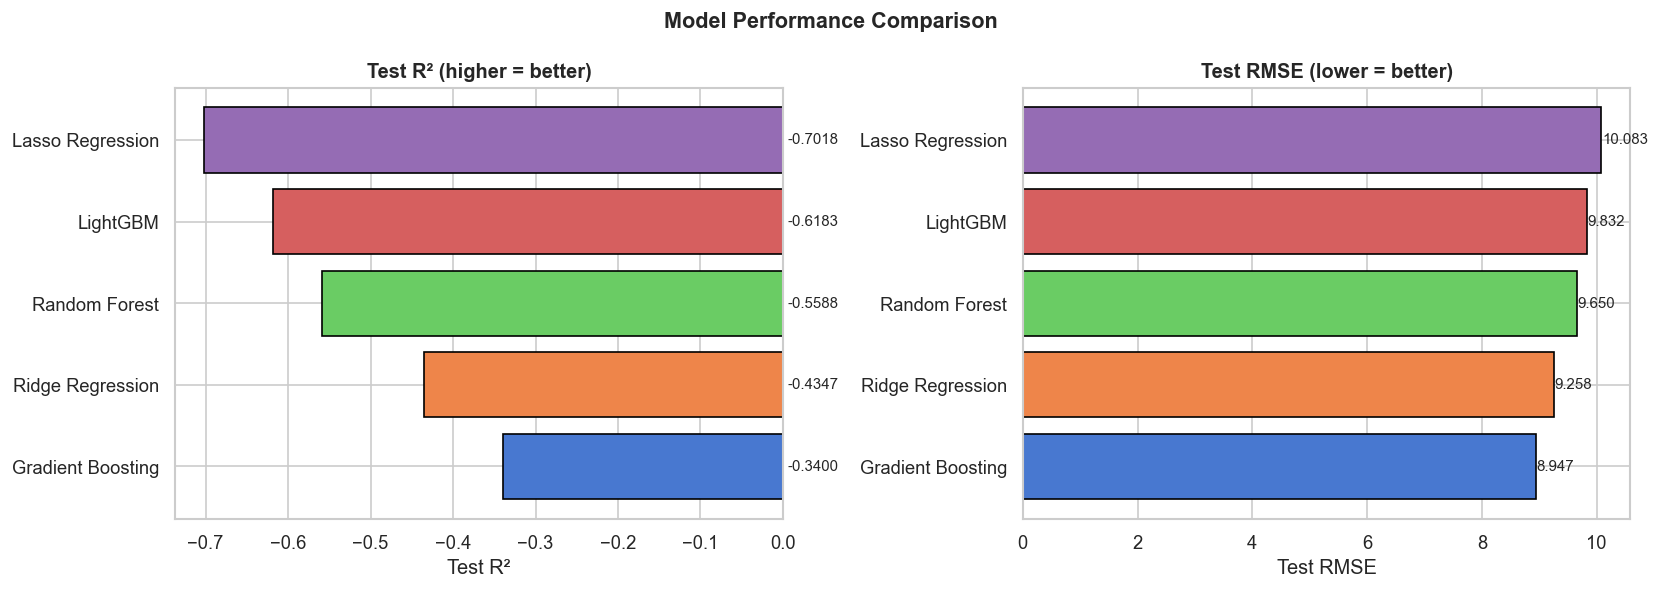

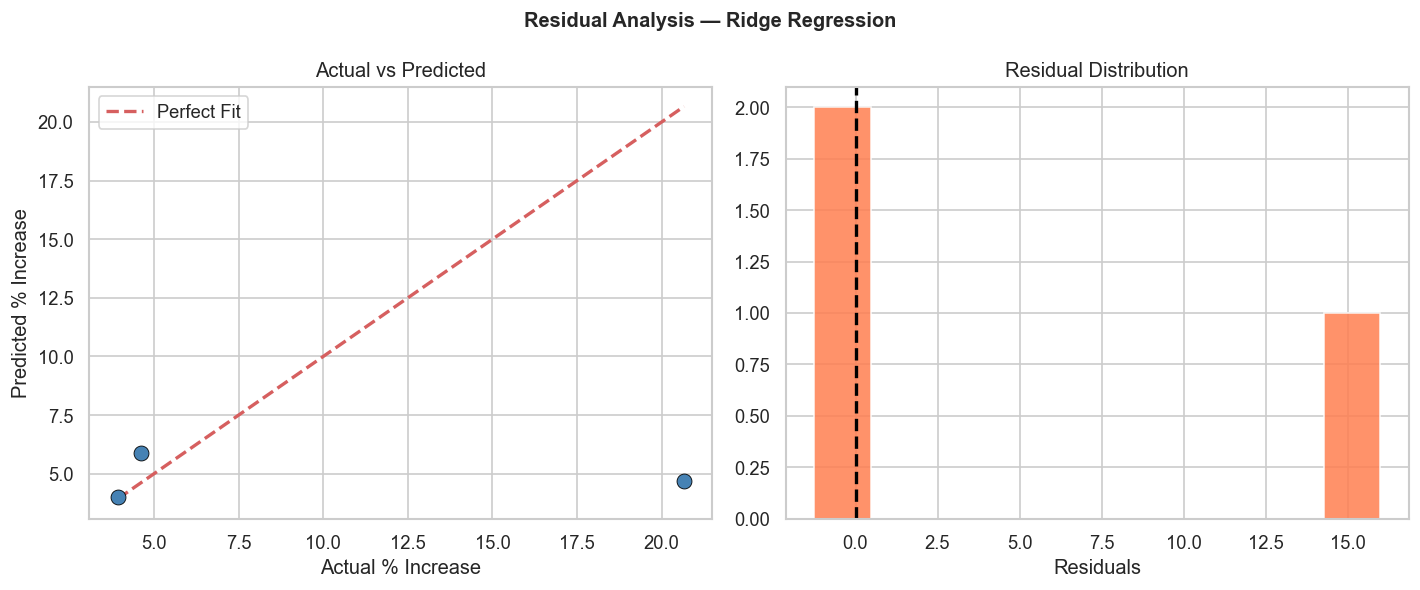

In [20]:
all_res = [r for r in [ridge_res, lasso_res, rf_res, gb_res, xgb_res, lgb_res] if r is not None]
print(f"✅ Successful models: {len(all_res)}")

if not all_res:
    print("❌ No models completed! Check errors above.")
else:
    rows = []
    for r in all_res:
        rows.append({
            'Model':      r['model_name'],
            'Train R²':   round(r['train_r2'], 4),
            'Test R²':    round(r['test_r2'],  4),
            'Test RMSE':  round(r['test_rmse'], 4),
            'Test MAE':   round(r['test_mae'],  4),
            'Test MAPE%': round(r['test_mape'], 2),
            'CV R²':      round(r['cv_mean'], 4) if r.get('cv_mean') is not None else float('nan')
        })
    cdf = pd.DataFrame(rows).sort_values('Test R²', ascending=False)
    display(cdf)

    best_res  = all_res[cdf['Test R²'].argmax()]
    best_name = best_res['model_name']
    print(f"\n🏆 BEST MODEL: {best_name}")
    print(f"   Test R²:    {best_res['test_r2']:.4f}")
    print(f"   Test RMSE:  {best_res['test_rmse']:.4f}")
    print(f"   Test MAPE:  {best_res['test_mape']:.2f}%")

    # Visual comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

    palette = sns.color_palette('muted', len(cdf))
    axes[0].barh(cdf['Model'], cdf['Test R²'], color=palette, edgecolor='black')
    axes[0].set_xlabel('Test R²'); axes[0].set_title('Test R² (higher = better)', fontweight='bold')
    for i, v in enumerate(cdf['Test R²']):
        axes[0].text(max(v, 0) + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

    axes[1].barh(cdf['Model'], cdf['Test RMSE'], color=palette, edgecolor='black')
    axes[1].set_xlabel('Test RMSE'); axes[1].set_title('Test RMSE (lower = better)', fontweight='bold')
    for i, v in enumerate(cdf['Test RMSE']):
        axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

    plt.tight_layout(); plt.show()

    # Actual vs Predicted
    y_pred_best = best_res['predictions']
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Residual Analysis — {best_name}', fontsize=12, fontweight='bold')

    axes[0].scatter(y_test, y_pred_best, color='steelblue', s=80, edgecolors='black', lw=0.5, zorder=5)
    mn_v, mx_v = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
    axes[0].plot([mn_v, mx_v], [mn_v, mx_v], 'r--', lw=2, label='Perfect Fit')
    axes[0].set_xlabel('Actual % Increase'); axes[0].set_ylabel('Predicted % Increase')
    axes[0].set_title('Actual vs Predicted'); axes[0].legend()

    residuals = y_test - y_pred_best
    axes[1].hist(residuals, bins=10, color='coral', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='black', lw=2, ls='--')
    axes[1].set_xlabel('Residuals'); axes[1].set_title('Residual Distribution')

    plt.tight_layout(); plt.show()

Linear model coefficients:


,Feature,Coefficient
6,Trend,-0.852473
4,Before_War_Price,-0.696704
19,price_multiplier,0.466370
17,Vulnerability,-0.426257
11,Oil_Import_Pct,-0.234710
10,Region_country,-0.234708
7,Before_War_USD,-0.232012
20,log_before_usd,-0.206812
3,Currency,0.200489
5,Unit,0.200489


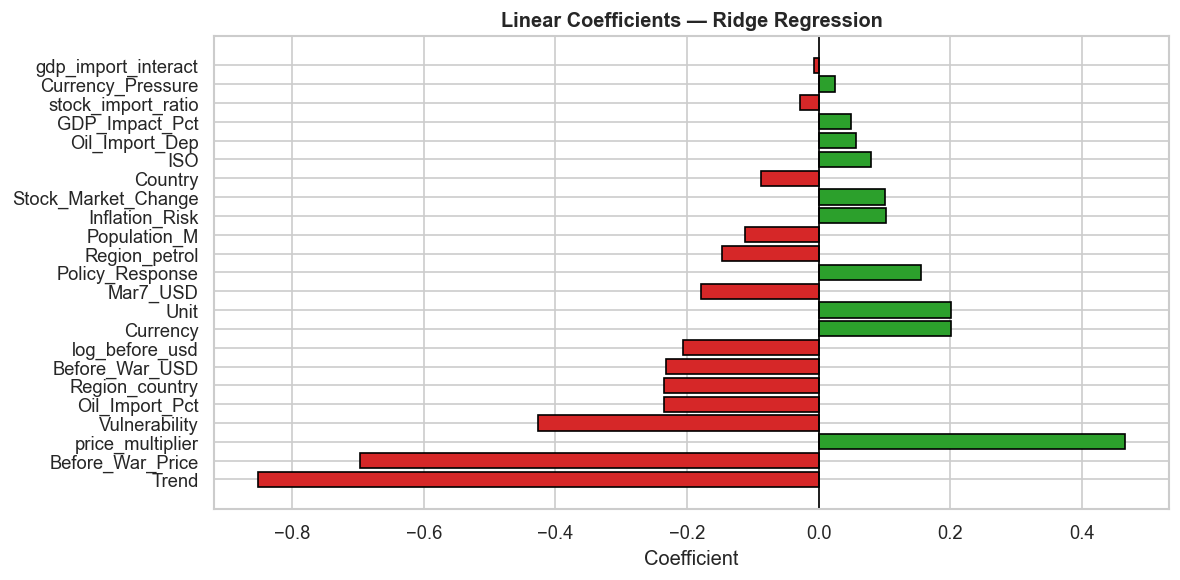

In [21]:
if all_res and hasattr(best_res['model'], 'feature_importances_'):
    try:
        importances = best_res['model'].feature_importances_
        if len(importances) == len(feature_cols):
            imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})                       .sort_values('Importance', ascending=False)

            print("Top features:")
            display(imp_df)

            top_n = min(15, len(imp_df))
            top   = imp_df.head(top_n)

            plt.figure(figsize=(10, 6))
            plt.barh(range(top_n), top['Importance'], color='steelblue', edgecolor='black')
            plt.yticks(range(top_n), top['Feature'])
            plt.xlabel('Importance Score', fontsize=12)
            plt.title(f'Top {top_n} Feature Importances — {best_name}', fontsize=13, fontweight='bold')
            plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
        else:
            print(f"⚠️  Mismatch: importances={len(importances)}, features={len(feature_cols)}")
    except Exception as e:
        print(f"❌ Feature importance failed: {e}")
elif all_res and hasattr(best_res['model'], 'coef_'):
    try:
        coef_df = pd.DataFrame({'Feature': feature_cols,
                                 'Coefficient': best_res['model'].coef_})                    .sort_values('Coefficient', key=abs, ascending=False)
        print("Linear model coefficients:")
        display(coef_df)

        plt.figure(figsize=(10, 5))
        colors = ['#d62728' if v < 0 else '#2ca02c' for v in coef_df['Coefficient']]
        plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
        plt.axvline(0, color='black', lw=1)
        plt.xlabel('Coefficient'); plt.title(f'Linear Coefficients — {best_name}', fontweight='bold')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"❌ Coefficient plot failed: {e}")
else:
    print("⚠️  No models completed for feature importance")

In [22]:
if all_res and hasattr(best_res['model'], 'feature_importances_'):
    try:
        import shap
        print("="*70)
        print("🔍 SHAP VALUE ANALYSIS")
        print("="*70)

        explainer = shap.TreeExplainer(best_res['model'])
        sample_n  = min(50, len(X_test))
        X_sample  = X_test.sample(n=sample_n, random_state=RANDOM_STATE)
        shap_vals = explainer.shap_values(X_sample)
        if isinstance(shap_vals, list): shap_vals = shap_vals[0]

        print("✅ SHAP values computed")

        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_vals, X_sample, plot_type='bar', show=False, max_display=15)
        plt.title(f'SHAP Importance — {best_name}', fontweight='bold')
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_vals, X_sample, show=False, max_display=15)
        plt.title(f'SHAP Beeswarm — {best_name}', fontweight='bold')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"⚠️  SHAP optional — skipped: {e}")
else:
    print("⚠️  SHAP not applicable for this model type")

⚠️  SHAP not applicable for this model type


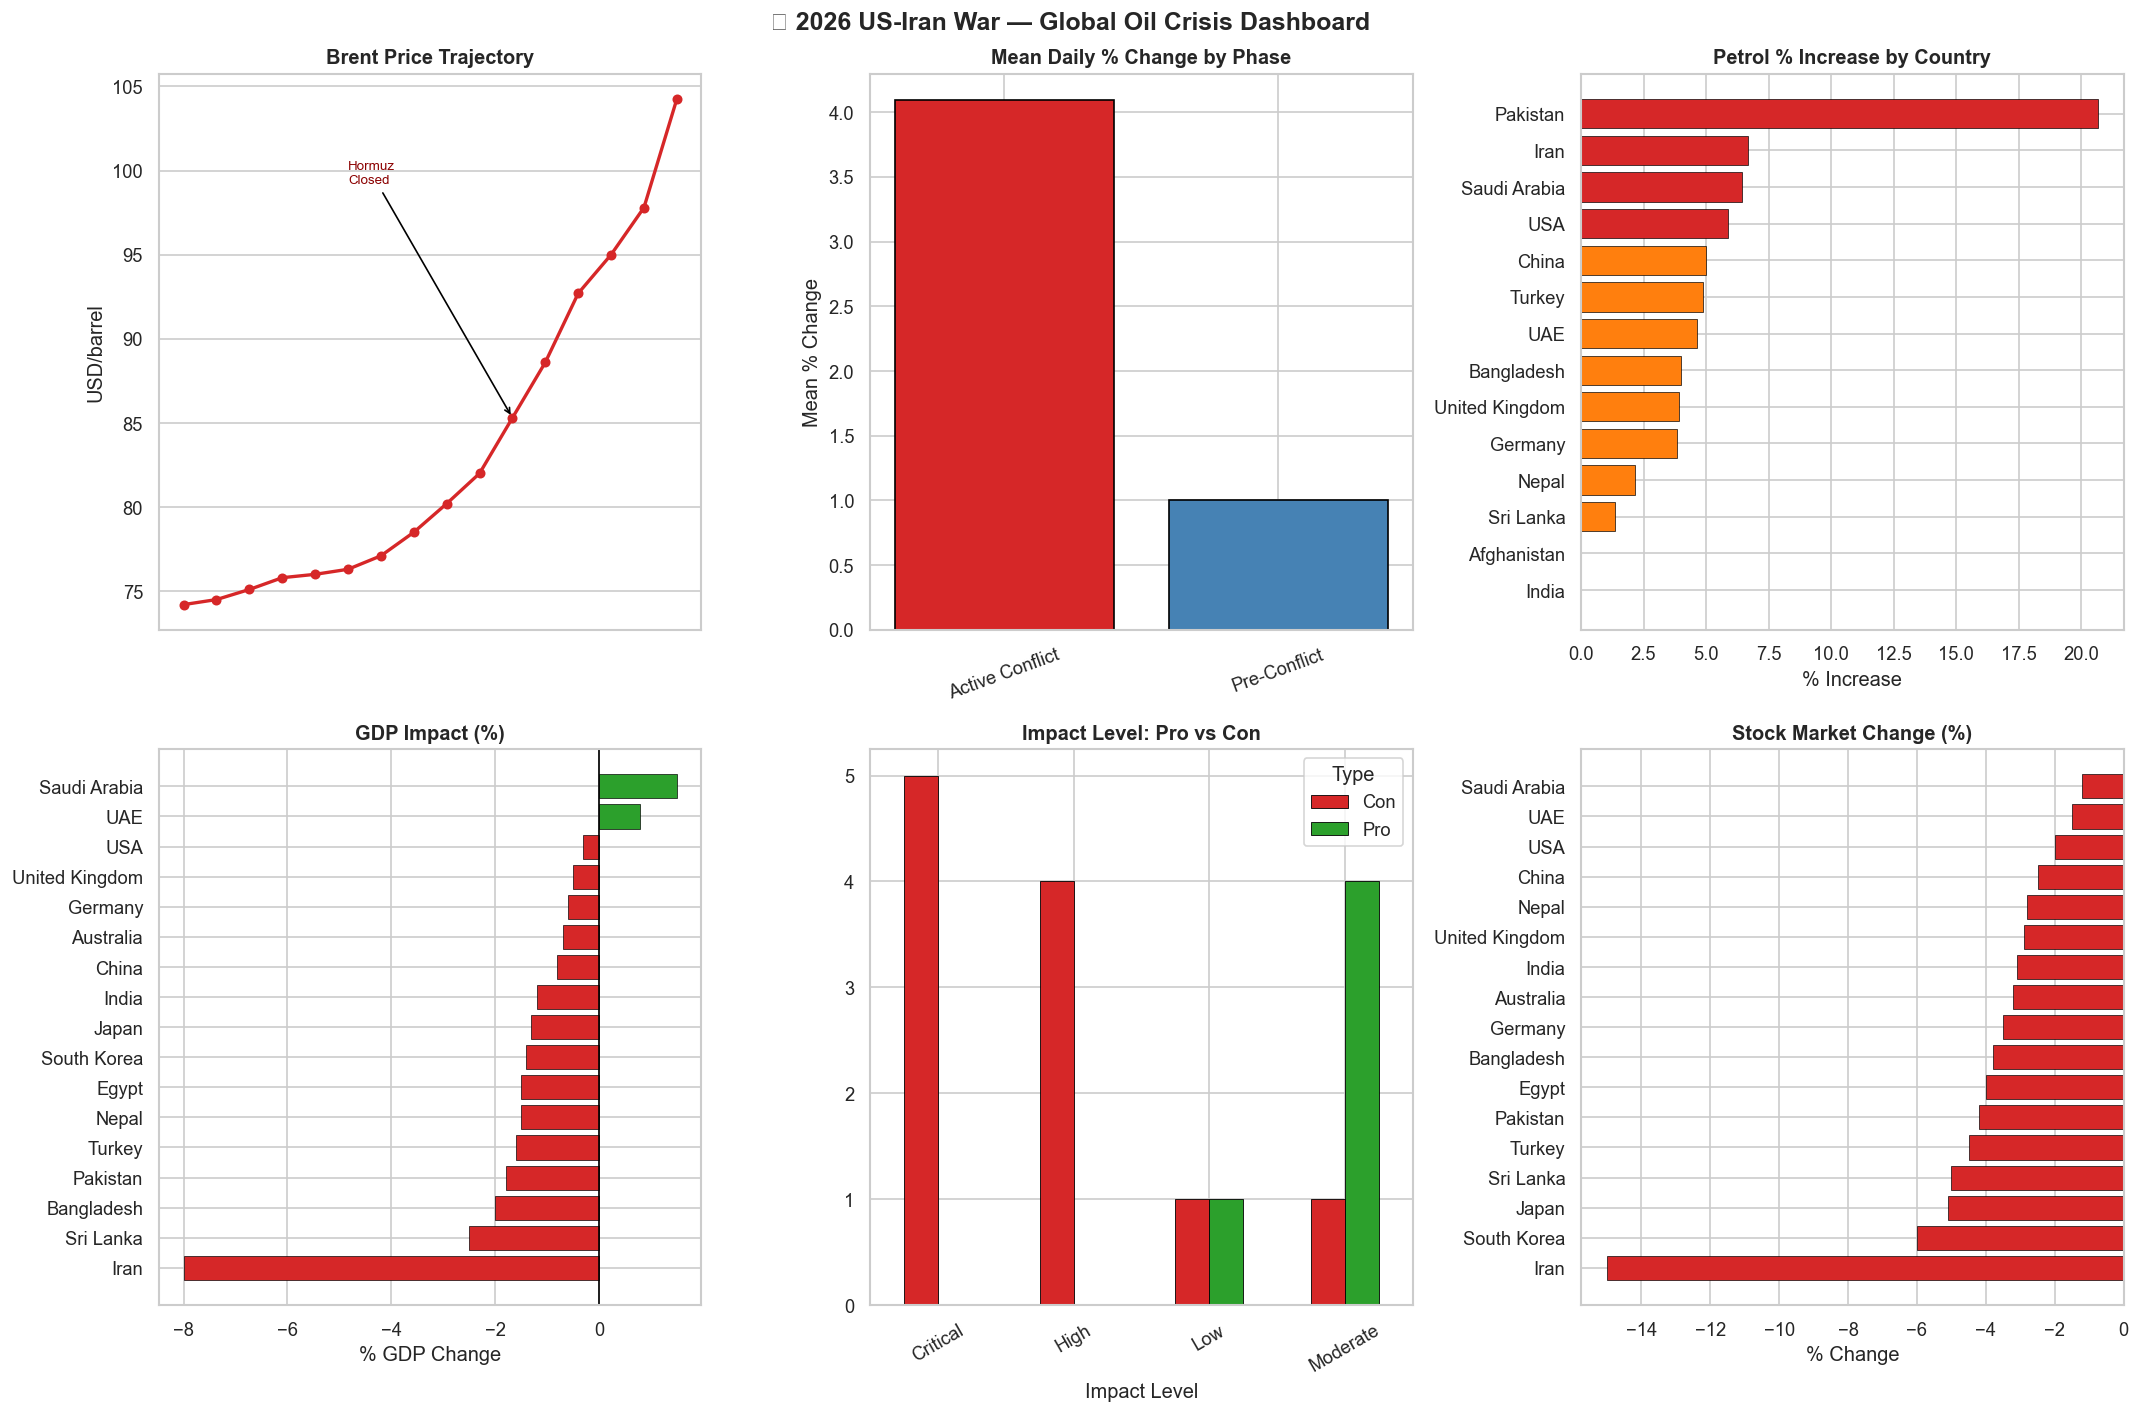

✅ Dashboard rendered


In [23]:
# ── Combined dashboard: crude oil surge + country vulnerability ─────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('🌐 2026 US-Iran War — Global Oil Crisis Dashboard', fontsize=15, fontweight='bold')

# Panel 1: Crude oil timeline with key events annotated
ax1 = fig.add_subplot(2, 3, 1)
if df_crude_c is not None:
    dc = df_crude_c.copy()
    date_col_ = next((c for c in dc.columns if 'date' in c.lower()), None)
    bc_ = next((c for c in dc.columns if 'brent' in c.lower() and 'usd' in c.lower()), None)
    if bc_ and date_col_:
        dc = dc.sort_values(date_col_)
        ax1.plot(range(len(dc)), dc[bc_], 'o-', color='#d62728', lw=2, ms=5)
        ax1.set_title('Brent Price Trajectory', fontweight='bold')
        ax1.set_ylabel('USD/barrel'); ax1.set_xticks([])
        ax1.annotate('Hormuz\nClosed', xy=(10, dc[bc_].iloc[10]),
                     xytext=(5, dc[bc_].max() - 5),
                     arrowprops=dict(arrowstyle='->', color='black'),
                     fontsize=8, color='darkred')

# Panel 2: Brent % surge by phase
ax2 = fig.add_subplot(2, 3, 2)
if df_crude_c is not None:
    phase_c = next((c for c in df_crude_c.columns if 'phase' in c.lower()), None)
    bc_chg  = next((c for c in df_crude_c.columns if 'brent' in c.lower() and 'pct' in c.lower()), None)
    if phase_c and bc_chg:
        grp = df_crude_c.groupby(phase_c)[bc_chg].mean().sort_values(ascending=False)
        ax2.bar(grp.index, grp.values,
                color=['#d62728' if 'Active' in k else 'steelblue' for k in grp.index],
                edgecolor='black')
        ax2.set_title('Mean Daily % Change by Phase', fontweight='bold')
        ax2.set_ylabel('Mean % Change'); ax2.tick_params(axis='x', rotation=20)

# Panel 3: Petrol % increase by country
ax3 = fig.add_subplot(2, 3, 3)
if df_petrol_c is not None:
    dp_ = df_petrol_c.copy()
    # decode country if already encoded
    try:
        ctry_lbl = le_dict.get('Country', le_dict.get('country', None))
        if ctry_lbl:
            dp_['Country_decoded'] = ctry_lbl.inverse_transform(dp_[next(c for c in dp_.columns if 'country' in c.lower())])
            c_name = 'Country_decoded'
        else:
            c_name = next((c for c in dp_.columns if 'country' in c.lower()), 'Country')
    except: c_name = next((c for c in dp_.columns if 'country' in c.lower()), 'Country')
    pct_c = next((c for c in dp_.columns if 'pct' in c.lower()), None)
    if pct_c and c_name:
        ds_ = dp_.sort_values(pct_c, ascending=True)
        colors_ = ['#d62728' if v > 5 else '#ff7f0e' if v > 0 else '#2ca02c' for v in ds_[pct_c]]
        ax3.barh(ds_[c_name] if c_name in ds_.columns else ds_.index,
                 ds_[pct_c], color=colors_, edgecolor='black', lw=0.4)
        ax3.set_title('Petrol % Increase by Country', fontweight='bold')
        ax3.set_xlabel('% Increase')

# Panel 4: GDP impact by country
ax4 = fig.add_subplot(2, 3, 4)
if df_country_c is not None:
    dc2 = df_country_c.copy()
    gdp_ = next((c for c in dc2.columns if 'gdp' in c.lower()), None)
    ctry_ = next((c for c in dc2.columns if 'country' in c.lower()), None)
    if gdp_ and ctry_:
        ds2_ = dc2.sort_values(gdp_)
        ax4.barh(ds2_[ctry_], ds2_[gdp_],
                 color=['#d62728' if v < 0 else '#2ca02c' for v in ds2_[gdp_]],
                 edgecolor='black', lw=0.4)
        ax4.axvline(0, color='black', lw=1)
        ax4.set_title('GDP Impact (%)', fontweight='bold')
        ax4.set_xlabel('% GDP Change')

# Panel 5: Pros vs Cons by impact
ax5 = fig.add_subplot(2, 3, 5)
if df_proscons_c is not None:
    dpc_ = df_proscons_c.copy()
    type_c_ = next((c for c in dpc_.columns if 'type' in c.lower()), None)
    impact_c_ = next((c for c in dpc_.columns if 'impact' in c.lower()), None)
    if type_c_ and impact_c_:
        ct_ = pd.crosstab(dpc_[impact_c_], dpc_[type_c_])
        ct_.plot(kind='bar', ax=ax5, color=['#d62728', '#2ca02c'][:len(ct_.columns)],
                 edgecolor='black', lw=0.5)
        ax5.set_title('Impact Level: Pro vs Con', fontweight='bold')
        ax5.set_xlabel('Impact Level'); ax5.legend(title='Type')
        ax5.tick_params(axis='x', rotation=30)

# Panel 6: Stock market crash
ax6 = fig.add_subplot(2, 3, 6)
if df_country_c is not None:
    stock_ = next((c for c in df_country_c.columns if 'stock' in c.lower()), None)
    ctry__ = next((c for c in df_country_c.columns if 'country' in c.lower()), None)
    if stock_ and ctry__:
        ds3_ = df_country_c.sort_values(stock_)
        ax6.barh(ds3_[ctry__], ds3_[stock_],
                 color=['#d62728' if v < 0 else '#2ca02c' for v in ds3_[stock_]],
                 edgecolor='black', lw=0.4)
        ax6.axvline(0, color='black', lw=1)
        ax6.set_title('Stock Market Change (%)', fontweight='bold')
        ax6.set_xlabel('% Change')

plt.tight_layout(); plt.show()
print("✅ Dashboard rendered")